# Fix lỗi đường dẫn

In [1]:
import os
import json
import time
from pathlib import Path
from collections import defaultdict

# ============================================================ #
# 1. CẤU HÌNH ĐƯỜNG DẪN TẬP TEST VÀ DỮ LIỆU GỐC                #
# ============================================================ #
TEST_DIR = Path("/kaggle/input/datasets/npnam0123/test-01/data_final")
FASHION_ROOT = Path("/kaggle/input/datasets/mayukh18/fashion200k-dataset")

# Thư mục chứa kết quả sau khi sửa lỗi thành công
FIXED_OUTPUT_DIR = Path("/kaggle/working/fixed_test_data")
FIXED_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


# ============================================================ #
# 2. HÀM CHUẨN HÓA VÀ LẬP CHỈ MỤC ẢNH                          #
# ============================================================ #
def normalize_path(path_str):
    """Chuẩn hóa đường dẫn về dạng chuẩn của Linux và loại bỏ tiền tố thừa."""
    p = str(path_str).replace("\\", "/").strip()
    if p.startswith("f200k_images/"):
        p = p[len("f200k_images/"):]
    if not p.startswith("women/"):
        p = "women/" + p
    return p

def infer_category(path_str):
    """Trích xuất danh mục thời trang từ đường dẫn."""
    valid = {"dresses", "jackets", "pants", "skirts", "tops"}
    for part in str(path_str).split("/"):
        if part in valid:
            return part
    return None

def build_image_index(root):
    """Quét toàn bộ thư mục gốc để băm (index) tất cả các ảnh thực tế."""
    print("\n[INFO] Đang lập chỉ mục (index) ảnh thật từ FASHION_ROOT...")
    start_time = time.time()
    
    rel_paths = set()
    by_filename = defaultdict(list)
    by_id_filename = defaultdict(list)
    by_cat_id_filename = defaultdict(list)
    
    # Duyệt qua tất cả các file ảnh trong thư mục dữ liệu gốc
    for img_path in root.rglob("*"):
        if img_path.is_file() and img_path.suffix.lower() in {".jpg", ".jpeg", ".png", ".webp"}:
            rel = img_path.relative_to(root).as_posix()
            rel_paths.add(rel)
            
            name = img_path.name
            parent_id = img_path.parent.name
            parts = Path(rel).parts
            category = parts[1] if len(parts) >= 3 else None
            
            by_filename[name].append(rel)
            by_id_filename[(parent_id, name)].append(rel)
            if category:
                by_cat_id_filename[(category, parent_id, name)].append(rel)
                
    print(f"[INFO] Tổng số ảnh tìm thấy thực tế: {len(rel_paths)} (Hoàn thành trong {time.time() - start_time:.2f}s)")
    return rel_paths, by_filename, by_id_filename, by_cat_id_filename

# Tiến hành chạy tạo index bộ ảnh
rel_paths, by_filename, by_id_filename, by_cat_id_filename = build_image_index(FASHION_ROOT)


# ============================================================ #
# 3. HÀM KHỚP ĐƯỜNG DẪN VÀ XỬ LÝ FILE                          #
# ============================================================ #
def resolve_exact_path(raw_path):
    """Tìm và sửa lỗi đường dẫn dựa trên bộ chỉ mục index đã tạo."""
    norm = normalize_path(raw_path)
    if norm in rel_paths:
        return norm
        
    name = Path(norm).name
    parent_id = Path(norm).parent.name
    category = infer_category(norm)
    
    # Chiến lược 1: Tìm theo Danh mục + ID thư mục + Tên file
    if category:
        candidates = by_cat_id_filename.get((category, parent_id, name), [])
        if len(candidates) == 1:
            return candidates[0]
            
    # Chiến lược 2: Tìm theo ID thư mục + Tên file
    candidates = by_id_filename.get((parent_id, name), [])
    if len(candidates) == 1:
        return candidates[0]
    elif len(candidates) > 1 and category:
        for c in candidates:
            if infer_category(c) == category:
                return c
        return candidates[0]
        
    # Chiến lược 3: Tìm duy nhất theo Tên file
    candidates = by_filename.get(name, [])
    if len(candidates) == 1:
        return candidates[0]
    elif len(candidates) > 1 and category:
        for c in candidates:
            if infer_category(c) == category:
                return c
        return candidates[0]
        
    return None

def process_test_file(filename):
    """Đọc một file JSON test lỗi, sửa toàn bộ đường dẫn ảnh và lưu file mới."""
    input_path = TEST_DIR / filename
    output_path = FIXED_OUTPUT_DIR / filename
    
    if not input_path.exists():
        return f"[ERROR] File không tồn tại: {input_path}"
        
    with open(input_path, "r", encoding="utf-8") as f:
        try:
            data = json.load(f)
        except Exception as e:
            return f"[ERROR] Không thể đọc file JSON {filename}: {e}"
            
    cleaned_data = []
    success_count = 0
    fail_count = 0
    
    for item in data:
        # Tìm lại đường dẫn chuẩn cho candidate và target
        fixed_cand = resolve_exact_path(item.get("candidate", ""))
        fixed_targ = resolve_exact_path(item.get("target", ""))
        
        if fixed_cand and fixed_targ:
            new_item = item.copy()
            new_item["candidate"] = fixed_cand
            new_item["target"] = fixed_targ
            cleaned_data.append(new_item)
            success_count += 1
        else:
            fail_count += 1
            
    # Lưu file đã làm sạch xuống thư mục đầu ra
    with open(output_path, "w", encoding="utf-8") as f:
        json.dump(cleaned_data, f, ensure_ascii=False, indent=4)
        
    return f"[SUCCESS] Đã xử lý [{filename}]: Hợp lệ {success_count} mẫu | Loại bỏ {fail_count} mẫu lỗi -> Đã lưu tại: {output_path}"


# ============================================================ #
# 4. THỰC THI CHÍNH: QUÉT VÀ SỬA TOÀN BỘ FILE TRONG THƯ MỤC   #
# ============================================================ #
if __name__ == "__main__":
    print("\n=======================================================")
    print("BẮT ĐẦU LÀM SẠCH TẤT CẢ FILE TEST TRONG THƯ MỤC DATA_FINAL")
    print("=======================================================")
    
    start_process_time = time.time()
    
    # Tự động quét tìm tất cả các file .json có trong thư mục test
    json_files = sorted([f.name for f in TEST_DIR.glob("*.json")])
    
    if not json_files:
        print(f"[WARNING] Không tìm thấy file JSON nào trong thư mục: {TEST_DIR}")
    else:
        print(f"[INFO] Tìm thấy {len(json_files)} file cần xử lý công việc: {json_files}\n")
        
        # Duyệt qua từng file và thực hiện sửa lỗi
        for fname in json_files:
            result_msg = process_test_file(fname)
            print(result_msg)
            
    print(f"\n[DONE] Hoàn tất xử lý tất cả các file trong {time.time() - start_process_time:.2f}s!")
    print(f"[ĐẦU RA] Toàn bộ file sạch đã sẵn sàng tại thư mục: {FIXED_OUTPUT_DIR}")


[INFO] Đang lập chỉ mục (index) ảnh thật từ FASHION_ROOT...
[INFO] Tổng số ảnh tìm thấy thực tế: 338339 (Hoàn thành trong 1268.93s)

BẮT ĐẦU LÀM SẠCH TẤT CẢ FILE TEST TRONG THƯ MỤC DATA_FINAL
[INFO] Tìm thấy 7 file cần xử lý công việc: ['dress_train_triplets_vi_google.json', 'fashion_test_combined_clean.json', 'fashion_train_combined_clean.json', 'jacket_train_triplets_vi_google.json', 'pants_train_triplets_vi_google.json', 'skirt_train_triplets_vi_google.json', 'top_train_triplets_vi_google.json']

[SUCCESS] Đã xử lý [dress_train_triplets_vi_google.json]: Hợp lệ 59082 mẫu | Loại bỏ 0 mẫu lỗi -> Đã lưu tại: /kaggle/working/fixed_test_data/dress_train_triplets_vi_google.json
[SUCCESS] Đã xử lý [fashion_test_combined_clean.json]: Hợp lệ 5000 mẫu | Loại bỏ 0 mẫu lỗi -> Đã lưu tại: /kaggle/working/fixed_test_data/fashion_test_combined_clean.json
[SUCCESS] Đã xử lý [fashion_train_combined_clean.json]: Hợp lệ 180136 mẫu | Loại bỏ 0 mẫu lỗi -> Đã lưu tại: /kaggle/working/fixed_test_data/fash

# Hiển thị mẫu

[INFO] Đang đọc dữ liệu từ: fashion_train_combined_clean.json...
[INFO] Tổng số mẫu có trong file train này: 180136

THÔNG TIN VĂN BẢN CỦA MẪU NGẪU NHIÊN
[CAPTIONS]: ['The top has a one-shoulder design with a long sleeve, it features a smooth texture and a longer hip-length cut, creating a sleek and modern look.']
[CAPTIONS_EN]: ['The top has a one-shoulder design with a long sleeve, it features a smooth texture and a longer hip-length cut, creating a sleek and modern look.']
[CAPTIONS_VI]: ['Phần trên có thiết kế một vai với tay áo dài, có họa tiết mịn và đường cắt dài hơn ngang hông, tạo vẻ bóng bẩy và hiện đại.']



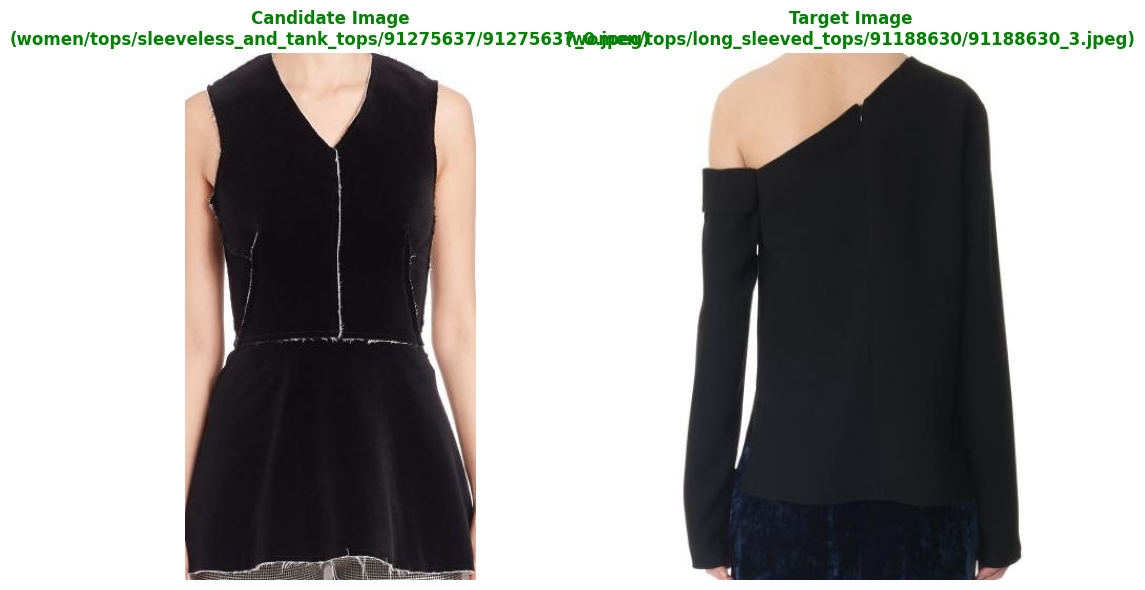

In [2]:
import json
import random
from pathlib import Path
import matplotlib.pyplot as plt
from PIL import Image

# ============================================================ #
# 1. CẤU HÌNH ĐƯỜNG DẪN DỮ LIỆU SẠCH VÀ GỐC                    #
# ============================================================ #
FIXED_OUTPUT_DIR = Path("/kaggle/working/fixed_test_data")
FASHION_ROOT = Path("/kaggle/input/datasets/mayukh18/fashion200k-dataset")

# 💡 BẠN CÓ THỂ ĐỔI TÊN FILE THEO MÔN HỌC/DANH MỤC MUỐN XEM TẠI ĐÂY:
# Các lựa chọn: 
# - 'fashion_train_combined_clean.json' (Toàn bộ tập Train gộp)
# - 'dress_train_triplets_vi_google.json' (Chỉ xem Váy)
# - 'jacket_train_triplets_vi_google.json' (Chỉ xem Áo khoác)
# - 'pants_train_triplets_vi_google.json' (Chỉ xem Quần)
# - 'skirt_train_triplets_vi_google.json' (Chỉ xem Chân váy)
# - 'top_train_triplets_vi_google.json' (Chỉ xem Áo thun/Áo kiểu)
TARGET_TRAIN_FILE = "fashion_train_combined_clean.json"

train_json_path = FIXED_OUTPUT_DIR / TARGET_TRAIN_FILE

# ============================================================ #
# 2. ĐỌC FILE TRAIN VÀ CHỌN MẪU NGẪU NHIÊN                     #
# ============================================================ #
if not train_json_path.exists():
    print(f"[ERROR] Không tìm thấy file dữ liệu: {train_json_path}")
    print("-> Hãy chắc chắn rằng bạn đã chạy Cell 1 để tạo ra các file sạch này.")
else:
    print(f"[INFO] Đang đọc dữ liệu từ: {TARGET_TRAIN_FILE}...")
    with open(train_json_path, "r", encoding="utf-8") as f:
        data = json.load(f)
        
    total_samples = len(data)
    print(f"[INFO] Tổng số mẫu có trong file train này: {total_samples}")
    
    # Bốc ngẫu nhiên 1 mẫu (1 cặp triplet / cặp tương tác)
    sample = random.choice(data)
    
    # ============================================================ #
    # 3. HIỂN THỊ THÔNG TIN VĂN BẢN (CAPTIIONS)                    #
    # ============================================================ #
    print("\n" + "="*50)
    print("THÔNG TIN VĂN BẢN CỦA MẪU NGẪU NHIÊN")
    print("="*50)
    for key, value in sample.items():
        if key not in ["candidate", "target"]:
            print(f"[{key.upper()}]: {value}")
    print("="*50 + "\n")
    
    # ============================================================ #
    # 4. TẢI VÀ HIỂN THỊ ẢNH GỐC (CANDIDATE) & ẢNH ĐÍCH (TARGET)   #
    # ============================================================ #
    # Ghép với đường dẫn gốc để lấy ảnh tuyệt đối
    cand_abs_path = FASHION_ROOT / sample["candidate"]
    targ_abs_path = FASHION_ROOT / sample["target"]
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 6))
    
    # Hàm đọc và hiển thị ảnh an toàn đề phòng file bị lỗi ổ đĩa
    def display_img(ax, img_path, title):
        try:
            if img_path.exists():
                img = Image.open(img_path)
                ax.imshow(img)
                ax.set_title(title, fontsize=12, fontweight='bold', color='green')
            else:
                ax.set_title(f"{title}\n(Lỗi: Không tìm thấy file ảnh thực tế)", color='red')
        except Exception as e:
            ax.set_title(f"{title}\n(Lỗi load ảnh: {e})", color='red')
        ax.axis("off")
        
    # Tiến hành vẽ hình lên notebook
    display_img(axes[0], cand_abs_path, f"Candidate Image\n({sample['candidate']})")
    display_img(axes[1], targ_abs_path, f"Target Image\n({sample['target']})")
    
    plt.tight_layout()
    plt.show()

# Thống kê

[+] Váy (Dresses)            :  59,082 captions
[+] Áo khoác (Jackets)       :  27,122 captions
[+] Quần (Pants)             :  31,644 captions
[+] Chân váy (Skirts)        :  35,120 captions
[+] Áo thun/Áo kiểu (Tops)   :  32,168 captions
-------------------------------------------------------
Tổng số lượng Caption trong tập TRAIN: 185,136 captions



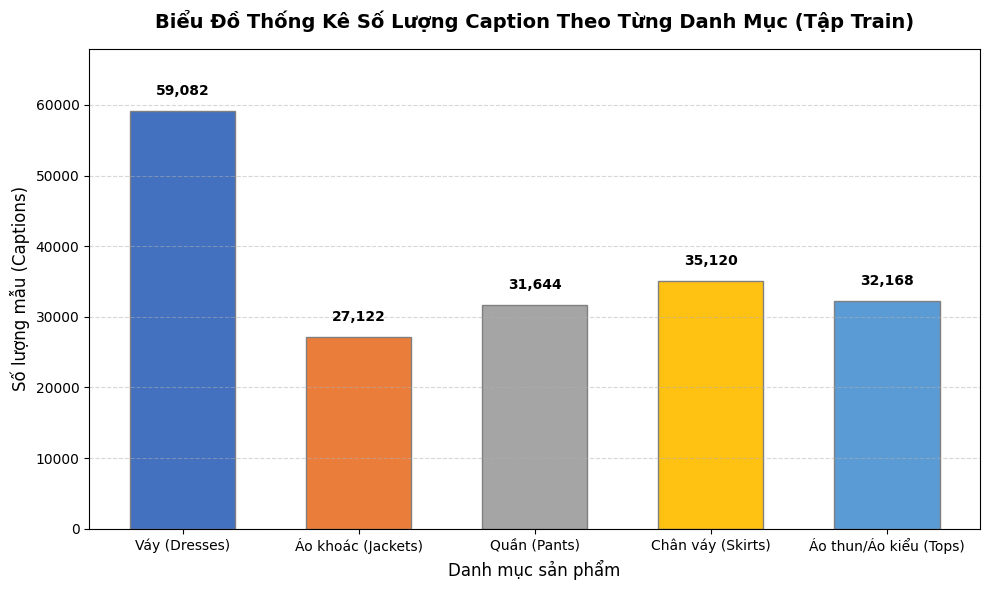

In [3]:
import json
from pathlib import Path
import matplotlib.pyplot as plt

# ============================================================ #
# 1. CẤU HÌNH ĐƯỜNG DẪN DỮ LIỆU SẠCH                          #
# ============================================================ #
FIXED_OUTPUT_DIR = Path("/kaggle/working/fixed_test_data")

# Tên các file train lẻ theo từng danh mục ảnh
train_files = {
    "Váy (Dresses)": "dress_train_triplets_vi_google.json",
    "Áo khoác (Jackets)": "jacket_train_triplets_vi_google.json",
    "Quần (Pants)": "pants_train_triplets_vi_google.json",
    "Chân váy (Skirts)": "skirt_train_triplets_vi_google.json",
    "Áo thun/Áo kiểu (Tops)": "top_train_triplets_vi_google.json"
}

# ============================================================ #
# 2. ĐỌC DỮ LIỆU VÀ THỐNG KÊ SỐ LƯỢNG CAPTION                  #
# ============================================================ #
category_counts = {}
total_captions = 0

print("=======================================================")
# BẮT ĐẦU THỐNG KÊ CHI TIẾT
print("=======================================================")

for cat_name, filename in train_files.items():
    file_path = FIXED_OUTPUT_DIR / filename
    
    if file_path.exists():
        with open(file_path, "r", encoding="utf-8") as f:
            data = json.load(f)
            # Mỗi một item (mẫu) trong file đại diện cho một cặp tương tác đi kèm caption
            count = len(data) 
            category_counts[cat_name] = count
            total_captions += count
            print(f"[+] {cat_name:<25}: {count:>7,} captions")
    else:
        category_counts[cat_name] = 0
        print(f"[WARNING] Không tìm thấy file: {filename}")

print("-" * 55)
print(f"Tổng số lượng Caption trong tập TRAIN: {total_captions:,} captions\n")

# ============================================================ #
# 3. TRỰC QUAN HÓA SỐ LIỆU BẰNG BIỂU ĐỒ BĂNG (BAR CHART)       #
# ============================================================ #
if total_captions > 0:
    categories = list(category_counts.keys())
    counts = list(category_counts.values())
    
    # Thiết lập kích thước biểu đồ
    plt.figure(figsize=(10, 6))
    
    # Vẽ biểu đồ cột kèm màu sắc sinh động
    colors = ['#4371bf', '#eb7d3b', '#a5a5a5', '#ffc212', '#5b9bd5']
    bars = plt.bar(categories, counts, color=colors, edgecolor='grey', width=0.6)
    
    # Thêm số liệu hiển thị trên đầu mỗi cột
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2.0, height + (total_captions * 0.01), 
                 f'{height:,}', ha='center', va='bottom', fontsize=10, fontweight='bold')
                 
    plt.title("Biểu Đồ Thống Kê Số Lượng Caption Theo Từng Danh Mục (Tập Train)", fontsize=14, fontweight='bold', pad=15)
    plt.xlabel("Danh mục sản phẩm", fontsize=12)
    plt.ylabel("Số lượng mẫu (Captions)", fontsize=12)
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.ylim(0, max(counts) * 1.15) # Tạo khoảng trống phía trên đỉnh cột để hiển thị chữ không bị đè
    
    plt.tight_layout()
    plt.show()

# Trích xuất vector cho PhoBERT(Unfreeze) hoặc PhoBERT (freeze). 

In [2]:
!pip install -q py_vncorenlp transformers pillow tqdm

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 49.1 MB/s eta 0:00:00


In [3]:
import os
import json
import torch
import torch.nn as nn
import torch.nn.functional as F
from pathlib import Path
from tqdm.auto import tqdm
from PIL import Image
import py_vncorenlp
from transformers import AutoTokenizer, AutoModel, CLIPModel, CLIPProcessor
from transformers import logging as transformers_logging

# Ẩn các cảnh báo từ Hugging Face để giao diện sạch đẹp
transformers_logging.set_verbosity_error()

# ============================================================ #
# 1. CẤU HÌNH ĐƯỜNG DẪN & THIẾT BỊ                            #
# ============================================================ #
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"[INFO] Đang sử dụng thiết bị: {DEVICE}")

FASHION_ROOT = Path("/kaggle/input/datasets/mayukh18/fashion200k-dataset")
FIXED_OUTPUT_DIR = Path("/kaggle/working/fixed_test_data")
FIXED_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# File JSON đầu vào cần trích xuất đặc trưng (Thay bằng file Train hoặc Test tùy nhu cầu)
DATA_JSON_PATH = FIXED_OUTPUT_DIR / "fashion_train_combined_clean.json"

# Đường dẫn file đầu ra để lưu Vector đặc trưng
SAVE_IMAGE_FEATURES_PATH = FIXED_OUTPUT_DIR / "image_features_precomputed.pt"
SAVE_TEXT_FEATURES_PATH = FIXED_OUTPUT_DIR / "text_features_precomputed.pt"

PHOBERT_CHECKPOINT = "/kaggle/input/datasets/npnam0123/phobert-false-01/student_best (2).pt"
FASHION_CLIP_NAME = "patrickjohncyh/fashion-clip"

# --- KHỞI TẠO VNCORENLP AN TOÀN CHỐNG SẬP VM ---
if 'rdrsegmenter' not in globals():
    if not os.path.exists('/kaggle/working/VnCoreNLP-1.2.jar'):
        print("[INFO] Đang tải file VnCoreNLP...")
        py_vncorenlp.download_model(save_dir='/kaggle/working')
    
    try:
        print("[INFO] Đang khởi động server VnCoreNLP...")
        rdrsegmenter = py_vncorenlp.VnCoreNLP(annotators=["wseg"], save_dir='/kaggle/working')
        print("[SUCCESS] VnCoreNLP đã sẵn sàng!")
    except ValueError as e:
        # Trường hợp biến rdrsegmenter bị xóa trong RAM nhưng JVM của Kaggle vẫn đang chạy ngầm
        if "VM is already running" in str(e):
            print("[INFO] JVM đang chạy ngầm từ trước. Đang kết nối lại...")
            # Ép buộc nạp thẳng từ jnius vào biến nếu VM đã hoạt động
            from jnius import autoclass
            rdrsegmenter = py_vncorenlp.VnCoreNLP(annotators=["wseg"], save_dir='/kaggle/working')
else:
    print("[INFO] Bộ tách từ VnCoreNLP đã được khởi tạo sẵn trong RAM, tiến hành bỏ qua!")


# ============================================================ #
# 2. KHAI BÁO KIẾN TRÚC PHOBERT STUDENT                        #
# ============================================================ #
class PhoBERTFashionCLIPStudent(nn.Module):
    def __init__(self, phobert_name="vinai/phobert-base-v2", out_dim=512):
        super().__init__()
        self.encoder = AutoModel.from_pretrained(phobert_name)
        hidden_size = self.encoder.config.hidden_size
        self.projection = nn.Sequential(
            nn.Linear(hidden_size, hidden_size),
            nn.GELU(),
            nn.LayerNorm(hidden_size),
            nn.Dropout(0.1),
            nn.Linear(hidden_size, out_dim),
        )
        
    def load_state_dict_flexible(self, checkpoint_path, device):
        checkpoint = torch.load(checkpoint_path, map_location=device)
        state_dict = checkpoint["model_state_dict"] if "model_state_dict" in checkpoint else checkpoint
        
        new_state_dict = {}
        for key, value in state_dict.items():
            new_key = key
            if key.startswith("roberta."):
                new_key = key.replace("roberta.", "encoder.", 1)
            new_state_dict[new_key] = value
            
        # Ép PyTorch trả về danh sách key thiếu/thừa
        missing_keys, unexpected_keys = self.load_state_dict(new_state_dict, strict=False)
        
        print("\n" + "="*50)
        print("🔍 KIỂM TRA TRỌNG SỐ PHOBERT STUDENT")
        print("="*50)
        if len(missing_keys) > 0:
            print(f"⚠️ Cảnh báo: Có {len(missing_keys)} tầng KHÔNG nạp được trọng số (bị thiếu):")
            # In ra các tầng thuộc lớp projection bị thiếu nếu có
            for k in missing_keys:
                if "projection" in k:
                    print(f"  -> {k} (Tầng chiếu chữ đang bị RANDOM!)")
        else:
            print("✅ Tuyệt vời: Toàn bộ các tầng đã được nạp đầy đủ, không thiếu key nào!")
        print("="*50 + "\n")

    def forward(self, input_ids, attention_mask):
        outputs = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        cls = outputs.last_hidden_state[:, 0, :]
        emb = self.projection(cls)
        return F.normalize(emb, dim=-1)


# ============================================================ #
# 3. NẠP MÔ HÌNH VÀ ĐỌC DỮ LIỆU                                #
# ============================================================ #
print("\n[INFO] Đang khởi tạo các mô hình Encoders...")
tokenizer = AutoTokenizer.from_pretrained("vinai/phobert-base-v2")

text_encoder = PhoBERTFashionCLIPStudent().to(DEVICE)
text_encoder.load_state_dict_flexible(PHOBERT_CHECKPOINT, DEVICE)
text_encoder.eval()

clip_model = CLIPModel.from_pretrained(FASHION_CLIP_NAME).to(DEVICE)
clip_processor = CLIPProcessor.from_pretrained(FASHION_CLIP_NAME)
clip_model.eval()

with open(DATA_JSON_PATH, "r", encoding="utf-8") as f:
    data_list = json.load(f)
print(f"[INFO] Tổng số lượng mẫu cần xử lý: {len(data_list)}")


# ============================================================ #
# 4. TRÍCH XUẤT VÀ LƯU VECTOR ĐẶC TRƯNG ẢNH (IMAGE EMBEDDINGS)  #
# ============================================================ #
# Gom toàn bộ các đường dẫn ảnh xuất hiện trong file JSON (Tránh trích xuất trùng lặp)
unique_images = set()
for item in data_list:
    unique_images.add(item["candidate"])
    unique_images.add(item["target"])
unique_images = list(unique_images)

image_features_dict = {}
print("\n[INFO] Bước 1: Đang trích xuất đặc trưng Ảnh qua FashionCLIP...")

with torch.no_grad():
    for i in tqdm(range(0, len(unique_images), 128), desc="Processing Images"):
        batch_paths = unique_images[i:i+128]
        images = []
        valid_paths = []
        
        for p in batch_paths:
            full_p = FASHION_ROOT / p
            if full_p.exists():
                try:
                    images.append(Image.open(full_p).convert("RGB"))
                    valid_paths.append(p)
                except Exception:
                    continue
                
        if not images: 
            continue
            
        inputs = clip_processor(images=images, return_tensors="pt").to(DEVICE)
        img_outputs = clip_model.get_image_features(**inputs)
        
        # Xử lý an toàn cấu trúc trả về đầu ra của mô hình CLIP
        if hasattr(img_outputs, "pooler_output") and img_outputs.pooler_output is not None:
            img_embs = img_outputs.pooler_output
        elif hasattr(img_outputs, "last_hidden_state"):
            img_embs = img_outputs.last_hidden_state[:, 0, :]
        else:
            img_embs = img_outputs
            
        img_embs = F.normalize(img_embs, dim=-1).cpu()
        
        # Lưu vào dictionary với Key là đường dẫn tương đối của ảnh
        for p, emb in zip(valid_paths, img_embs):
            image_features_dict[p] = emb

# Thực hiện lưu đặc trưng ảnh xuống ổ đĩa
torch.save(image_features_dict, SAVE_IMAGE_FEATURES_PATH)
print(f"[DONE] Đã trích xuất và lưu {len(image_features_dict)} đặc trưng ảnh tại: {SAVE_IMAGE_FEATURES_PATH}")


# ============================================================ #
# 5. TRÍCH XUẤT VÀ LƯU VECTOR ĐẶC TRƯNG VĂN BẢN (TEXT EMBEDDINGS)#
# ============================================================ #
text_features_list = []
print("\n[INFO] Bước 2: Đang trích xuất đặc trưng Văn bản tiếng Việt qua PhoBERT Student...")

with torch.no_grad():
    for i in tqdm(range(0, len(data_list), 128), desc="Processing Texts"):
        batch_items = data_list[i:i+128]
        captions_segmented = []
        
        for item in batch_items:
            # Lấy câu tiếng Việt thô từ cấu trúc dữ liệu JSON của bạn
            raw_vi = item.get("captions_vi", item.get("text_vi", [""]))[0]
            # Tách từ bằng VnCoreNLP
            seg_vi = rdrsegmenter.word_segment(raw_vi)[0]
            captions_segmented.append(seg_vi)
            
        inputs = tokenizer(captions_segmented, padding=True, truncation=True, max_length=128, return_tensors="pt").to(DEVICE)
        txt_embs = text_encoder(inputs["input_ids"], inputs["attention_mask"]).cpu()
        
        # Thêm danh sách tensor vào mảng tổng
        for emb in txt_embs:
            text_features_list.append(emb)

# Chuyển đổi list thành một Tensor lớn duy nhất kích thước [Num_Samples, 512]
text_features_tensor = torch.stack(text_features_list)

# Thực hiện lưu đặc trưng văn bản xuống ổ đĩa
torch.save(text_features_tensor, SAVE_TEXT_FEATURES_PATH)
print(f"[DONE] Đã trích xuất và lưu {text_features_tensor.shape[0]} đặc trưng văn bản tại: {SAVE_TEXT_FEATURES_PATH}")

# Dọn dẹp bộ nhớ GPU giải phóng tài nguyên hoàn toàn
del clip_model, text_encoder
torch.cuda.empty_cache()
print("\n[SUCCESS] Hoàn thành lưu trữ toàn bộ dữ liệu đặc trưng định dạng toán học!")

[INFO] Đang sử dụng thiết bị: cuda
[INFO] Đang tải file VnCoreNLP...


--2026-06-07 00:20:14--  https://raw.githubusercontent.com/vncorenlp/VnCoreNLP/master/VnCoreNLP-1.2.jar
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.110.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.109.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 27412703 (26M) [application/octet-stream]
Saving to: ‘VnCoreNLP-1.2.jar’

     0K .......... .......... .......... .......... ..........  0% 33.1M 1s
    50K .......... .......... .......... .......... ..........  0% 30.8M 1s
   100K .......... .......... .......... .......... ..........  0% 95.9M 1s
   150K .......... .......... .......... .......... ..........  0% 42.9M 1s
   200K .......... .......... .......... .......... ..........  0%  170M 1s
   250K .......... .......... .......... .......... ..........  1%  152M 0s
   300K .......... .......... .......... .......... ..........  1% 90.1M 0s
   350K ..

[INFO] Đang khởi động server VnCoreNLP...
2026-06-07 00:20:17 INFO  WordSegmenter:24 - Loading Word Segmentation model
[SUCCESS] VnCoreNLP đã sẵn sàng!

[INFO] Đang khởi tạo các mô hình Encoders...


config.json:   0%|          | 0.00/678 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

...

[INFO] Tổng số lượng mẫu cần xử lý: 180136

[INFO] Bước 1: Đang trích xuất đặc trưng Ảnh qua FashionCLIP...


Processing Images:   0%|          | 0/1426 [00:00<?, ?it/s]

[DONE] Đã trích xuất và lưu 182410 đặc trưng ảnh tại: /kaggle/working/fixed_test_data/image_features_precomputed.pt

[INFO] Bước 2: Đang trích xuất đặc trưng Văn bản tiếng Việt qua PhoBERT Student...


Processing Texts:   0%|          | 0/1408 [00:00<?, ?it/s]

[DONE] Đã trích xuất và lưu 180136 đặc trưng văn bản tại: /kaggle/working/fixed_test_data/text_features_precomputed.pt

[SUCCESS] Hoàn thành lưu trữ toàn bộ dữ liệu đặc trưng định dạng toán học!


# Trích xuất vector cho mô hình baseline

In [13]:
import os
import json
import torch
import torch.nn.functional as F
from pathlib import Path
from tqdm.auto import tqdm
from PIL import Image
from transformers import CLIPModel, CLIPProcessor
from transformers import logging as transformers_logging

# Ẩn cảnh báo
transformers_logging.set_verbosity_error()

# ============================================================ #
# 1. CẤU HÌNH ĐƯỜNG DẪN & THIẾT BỊ                             #
# ============================================================ #
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"[INFO] Đang sử dụng thiết bị: {DEVICE}")

FASHION_ROOT = Path("/kaggle/input/datasets/mayukh18/fashion200k-dataset")
OUTPUT_DIR = Path("/kaggle/working/extracted_features_distilled")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# File JSON chứa dữ liệu (Thay bằng file Train hoặc Test tùy nhu cầu)
DATA_JSON_PATH = Path("/kaggle/working/fixed_test_data/fashion_train_combined_clean.json") 

# Đường dẫn file đầu ra
SAVE_IMAGE_FEATURES_PATH = OUTPUT_DIR / "image_features_distilled.pt"
SAVE_TEXT_FEATURES_PATH = OUTPUT_DIR / "text_features_distilled.pt"

# Tên mô hình gốc và đường dẫn trọng số đã fine-tune
MODEL_NAME = "patrickjohncyh/fashion-clip"
CHECKPOINT_PATH = "/kaggle/input/datasets/npnam0123/fashionclip-nophobert/clip_direct_epoch_3.pt"
MAX_LENGTH = 77  # Phải khớp với lúc training

# ============================================================ #
# 2. NẠP MÔ HÌNH VÀ TRỌNG SỐ ĐÃ CHƯNG CẤT                      #
# ============================================================ #
print("\n[INFO] Đang khởi tạo FashionCLIP và Processor gốc...")
processor = CLIPProcessor.from_pretrained(MODEL_NAME)
model = CLIPModel.from_pretrained(MODEL_NAME).to(DEVICE)

print(f"[INFO] Đang nạp trọng số đã Fine-tune từ: {CHECKPOINT_PATH}")
checkpoint = torch.load(CHECKPOINT_PATH, map_location=DEVICE)

# Xử lý an toàn cấu trúc file checkpoint
state_dict = checkpoint["model_state_dict"] if "model_state_dict" in checkpoint else checkpoint

# Ép PyTorch báo cáo nếu có bất đồng bộ key
missing_keys, unexpected_keys = model.load_state_dict(state_dict, strict=False)
if len(missing_keys) > 0:
    print(f"⚠️ Cảnh báo: Có {len(missing_keys)} keys bị thiếu.")
else:
    print("✅ Tuyệt vời: Toàn bộ trọng số đã được nạp khớp 100%!")

model.eval()

# ============================================================ #
# 3. ĐỌC DỮ LIỆU                                               #
# ============================================================ #
with open(DATA_JSON_PATH, "r", encoding="utf-8") as f:
    data_list = json.load(f)
print(f"[INFO] Tổng số lượng mẫu cần xử lý: {len(data_list)}")

# ============================================================ #
# 4. TRÍCH XUẤT ĐẶC TRƯNG ẢNH (IMAGE EMBEDDINGS)               #
# ============================================================ #
unique_images = set()
for item in data_list:
    if "candidate" in item: unique_images.add(item["candidate"])
    if "target" in item: unique_images.add(item["target"])
unique_images = list(unique_images)

image_features_dict = {}
print("\n[INFO] Bước 1: Đang trích xuất đặc trưng Ảnh qua Vision Model...")

with torch.no_grad():
    for i in tqdm(range(0, len(unique_images), 128), desc="Processing Images"):
        batch_paths = unique_images[i:i+128]
        images, valid_paths = [], []
        
        for p in batch_paths:
            full_p = FASHION_ROOT / p
            if full_p.exists():
                try:
                    images.append(Image.open(full_p).convert("RGB"))
                    valid_paths.append(p)
                except Exception:
                    continue
                
        if not images: continue
            
        inputs = processor(images=images, return_tensors="pt").to(DEVICE)
        img_outputs = model.get_image_features(**inputs)
        
        # --- LẤY TENSOR AN TOÀN ---
        if torch.is_tensor(img_outputs):
            img_embs = img_outputs
        else:
            if hasattr(img_outputs, "image_embeds") and img_outputs.image_embeds is not None:
                img_embs = img_outputs.image_embeds
            elif hasattr(img_outputs, "pooler_output"):
                img_embs = img_outputs.pooler_output
                # Đi qua lớp Visual Projection nếu cần
                if hasattr(model, "visual_projection") and img_embs.shape[-1] != model.config.projection_dim:
                    img_embs = model.visual_projection(img_embs)
            else:
                img_embs = img_outputs[0]
        
        # Đảm bảo là tensor 2D
        if img_embs.dim() == 3:
            img_embs = img_embs[:, 0, :]
            
        # Chuẩn hóa L2 ngay lập tức
        img_embs = F.normalize(img_embs, p=2, dim=-1).cpu()
        
        for p, emb in zip(valid_paths, img_embs):
            image_features_dict[p] = emb

torch.save(image_features_dict, SAVE_IMAGE_FEATURES_PATH)
print(f"[DONE] Đã trích xuất và lưu {len(image_features_dict)} đặc trưng ảnh.")

# ============================================================ #
# 5. TRÍCH XUẤT ĐẶC TRƯNG VĂN BẢN (TEXT EMBEDDINGS)            #
# ============================================================ #
text_features_list = []
print("\n[INFO] Bước 2: Đang trích xuất đặc trưng Văn bản qua Fine-tuned Text Model...")

with torch.no_grad():
    for i in tqdm(range(0, len(data_list), 128), desc="Processing Texts"):
        batch_items = data_list[i:i+128]
        raw_captions = []
        
        for item in batch_items:
            # Lấy câu tiếng Việt (không cần VnCoreNLP nữa)
            raw_vi = item.get("captions_vi", item.get("text_vi", [""]))[0]
            raw_captions.append(raw_vi)
            
        inputs = processor(
            text=raw_captions, 
            padding="max_length", 
            truncation=True, 
            max_length=MAX_LENGTH, 
            return_tensors="pt"
        ).to(DEVICE)
        
        txt_outputs = model.get_text_features(
            input_ids=inputs["input_ids"], 
            attention_mask=inputs["attention_mask"]
        )
        
        # --- LẤY TENSOR AN TOÀN ---
        if torch.is_tensor(txt_outputs):
            txt_embs = txt_outputs
        else:
            if hasattr(txt_outputs, "text_embeds") and txt_outputs.text_embeds is not None:
                txt_embs = txt_outputs.text_embeds
            elif hasattr(txt_outputs, "pooler_output"):
                txt_embs = txt_outputs.pooler_output
                # Đi qua lớp Text Projection nếu cần
                if hasattr(model, "text_projection") and txt_embs.shape[-1] != model.config.projection_dim:
                    txt_embs = model.text_projection(txt_embs)
            else:
                txt_embs = txt_outputs[0]
                
        # Đảm bảo là tensor 2D
        if txt_embs.dim() == 3:
            txt_embs = txt_embs[:, 0, :]
            
        # Chuẩn hóa L2 ngay lập tức
        txt_embs = F.normalize(txt_embs, p=2, dim=-1).cpu()
        
        for emb in txt_embs:
            text_features_list.append(emb)

text_features_tensor = torch.stack(text_features_list)
torch.save(text_features_tensor, SAVE_TEXT_FEATURES_PATH)
print(f"[DONE] Đã trích xuất và lưu {text_features_tensor.shape[0]} đặc trưng văn bản.")

# Dọn dẹp
del model
torch.cuda.empty_cache()
print("\n[SUCCESS] Hoàn tất toàn bộ quá trình trích xuất!")

[INFO] Đang sử dụng thiết bị: cuda

[INFO] Đang khởi tạo FashionCLIP và Processor gốc...


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

[INFO] Đang nạp trọng số đã Fine-tune từ: /kaggle/input/datasets/npnam0123/fashionclip-nophobert/clip_direct_epoch_3.pt
✅ Tuyệt vời: Toàn bộ trọng số đã được nạp khớp 100%!
[INFO] Tổng số lượng mẫu cần xử lý: 180136

[INFO] Bước 1: Đang trích xuất đặc trưng Ảnh qua Vision Model...


Processing Images:   0%|          | 0/1426 [00:00<?, ?it/s]

[DONE] Đã trích xuất và lưu 182410 đặc trưng ảnh.

[INFO] Bước 2: Đang trích xuất đặc trưng Văn bản qua Fine-tuned Text Model...


Processing Texts:   0%|          | 0/1408 [00:00<?, ?it/s]

[DONE] Đã trích xuất và lưu 180136 đặc trưng văn bản.

[SUCCESS] Hoàn tất toàn bộ quá trình trích xuất!


# Huấn luyện MLP của mô hình baseline

[INFO] Đang sử dụng thiết bị: cuda
[INFO] Đang nạp các file đặc trưng precomputed từ ổ đĩa...
[SUCCESS] Đã nạp 182410 ảnh và 180136 vector chữ vào RAM!

[START] Bắt đầu huấn luyện mạng MLP Combiner với InfoNCE Loss trong 15 Epochs...


Epoch 1/15:   0%|          | 0/351 [00:00<?, ?it/s]

-> Epoch 1/15 | InfoNCE Training Loss: 3.1232



Epoch 2/15:   0%|          | 0/351 [00:00<?, ?it/s]

-> Epoch 2/15 | InfoNCE Training Loss: 2.8691



...

-> Epoch 13/15 | InfoNCE Training Loss: 2.4763



Epoch 14/15:   0%|          | 0/351 [00:00<?, ?it/s]

-> Epoch 14/15 | InfoNCE Training Loss: 2.4569



Epoch 15/15:   0%|          | 0/351 [00:00<?, ?it/s]

-> Epoch 15/15 | InfoNCE Training Loss: 2.4412

[DONE] Đã lưu mô hình tại: /kaggle/working/fixed_test_data/mlp_combiner_infonce.pt
[INFO] Đang vẽ biểu đồ học tập của mạng MLP...
[DONE] Biểu đồ hoàn tất! Đã lưu tại: /kaggle/working/fixed_test_data/mlp_infonce_loss_curve.png


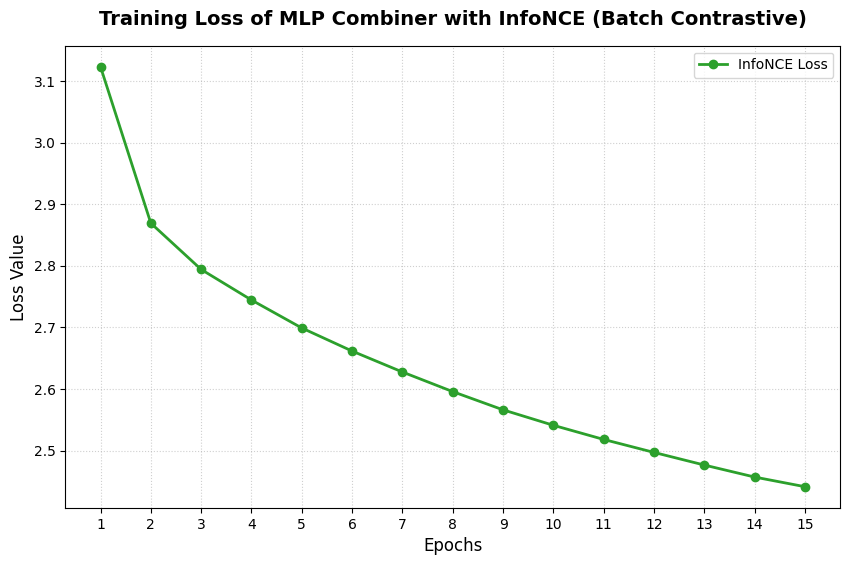

In [14]:
import os
import json
import time
import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from pathlib import Path
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

# ============================================================ #
# 1. CẤU HÌNH & THIẾT BỊ                                       #
# ============================================================ #
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"[INFO] Đang sử dụng thiết bị: {DEVICE}")

# Thư mục chứa file JSON gốc
FIXED_OUTPUT_DIR = Path("/kaggle/working/fixed_test_data")
TRAIN_JSON_PATH = FIXED_OUTPUT_DIR / "fashion_train_combined_clean.json"

# Thư mục chứa file đặc trưng đã trích xuất từ bước trước
EXTRACTED_DIR = Path("/kaggle/working/extracted_features_distilled")

# Sửa lại đúng đường dẫn load file .pt
LOAD_IMAGE_FEATURES_PATH = EXTRACTED_DIR / "image_features_distilled.pt"
LOAD_TEXT_FEATURES_PATH = EXTRACTED_DIR / "text_features_distilled.pt"

# ============================================================ #
# 2. KIẾN TRÚC MẠNG MLP COMBINER (BASELINE)                    #
# ============================================================ #
class MLPCombiner(nn.Module):
    def __init__(self, input_dim=512, hidden_dim=1024, output_dim=512):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(input_dim * 2, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.3),
            
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.BatchNorm1d(hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(0.2),
            
            nn.Linear(hidden_dim // 2, output_dim)
        )
        
    def forward(self, image_emb, text_emb):
        x = torch.cat([image_emb, text_emb], dim=-1)
        out = self.mlp(x)
        return F.normalize(out, dim=-1)


# ============================================================ #
# 3. ĐỊNH NGHĨA HÀM LOSS INFONCE & DATASET NÂNG CẤP            #
# ============================================================ #
class InfoNCELoss(nn.Module):
    """
    Hàm loss Contrastive dựa trên Batch (InfoNCE).
    Ép ma trận dự đoán phải trùng khớp với ma trận mục tiêu trên đường chéo chính,
    đồng thời đẩy xa tất cả các mẫu khác xuất hiện trong cùng một Batch.
    """
    def __init__(self, temperature=0.07):
        super().__init__()
        self.temperature = temperature
        
    def forward(self, predicted_target, pos_emb):
        # Đảm bảo các vector mục tiêu cũng đã được chuẩn hóa L2
        pos_emb = F.normalize(pos_emb, dim=-1)
        
        # Tính toán ma trận tương đồng giữa các mẫu trong Batch: [Batch_Size, Batch_Size]
        # Mỗi hàng i đại diện cho điểm tương đồng của truy vấn i với tất cả ảnh đích j trong batch
        logits = torch.matmul(predicted_target, pos_emb.T) / self.temperature
        
        # Nhãn đúng (Ground Truth) chính là vị trí đường chéo chính (i == j)
        batch_size = predicted_target.size(0)
        labels = torch.arange(batch_size, device=predicted_target.device)
        
        # Sử dụng Cross Entropy để tối ưu hóa đồng thời lực hút đường chéo và lực đẩy xung quanh
        loss = F.cross_entropy(logits, labels)
        return loss

class SavedFeatureContrastiveDataset(Dataset):
    """ Dataset rút gọn: Không cần bốc mẫu Negative ngẫu nhiên nữa """
    def __init__(self, image_features_dict, text_features_tensor, data_list):
        self.image_features = image_features_dict
        self.text_features = text_features_tensor
        self.data_list = data_list
        
    def __len__(self):
        return len(self.data_list)
        
    def __getitem__(self, idx):
        item = self.data_list[idx]
        cand_path = item["candidate"]
        targ_path = item["target"]
        
        cand_emb = self.image_features[cand_path]
        pos_emb = self.image_features[targ_path]
        text_emb = self.text_features[idx]
        
        return cand_emb, text_emb, pos_emb


# ============================================================ #
# 4. NẠP DỮ LIỆU ĐẶC TRƯNG ĐÃ TÍNH TOÁN TRƯỚC                  #
# ============================================================ #
print("[INFO] Đang nạp các file đặc trưng precomputed từ ổ đĩa...")
with open(TRAIN_JSON_PATH, "r", encoding="utf-8") as f:
    train_data = json.load(f)

image_features_dict = torch.load(LOAD_IMAGE_FEATURES_PATH, map_location="cpu")
text_features_tensor = torch.load(LOAD_TEXT_FEATURES_PATH, map_location="cpu")

print(f"[SUCCESS] Đã nạp {len(image_features_dict)} ảnh và {text_features_tensor.shape[0]} vector chữ vào RAM!")


# ============================================================ #
# 5. TIẾN HÀNH HUẤN LUYỆN MẠNG MLP VỚI INFONCE LOSS            #
# ============================================================ #
train_dataset = SavedFeatureContrastiveDataset(image_features_dict, text_features_tensor, train_data)

# CHÚ Ý: Bắt buộc phải đặt drop_last=True để kích thước ma trận vuông [512, 512] đồng nhất ở batch cuối
train_loader = DataLoader(train_dataset, batch_size=512, shuffle=True, drop_last=True)

mlp_model = MLPCombiner(input_dim=512, hidden_dim=1024, output_dim=512).to(DEVICE)
criterion = InfoNCELoss(temperature=0.07)
optimizer = torch.optim.AdamW(mlp_model.parameters(), lr=1e-3, weight_decay=1e-4)

epochs = 15
mlp_loss_history = []

print(f"\n[START] Bắt đầu huấn luyện mạng MLP Combiner với InfoNCE Loss trong {epochs} Epochs...")
for epoch in range(epochs):
    mlp_model.train()
    epoch_loss = 0.0
    
    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}")
    for cand_emb, text_emb, pos_emb in pbar:
        cand_emb = cand_emb.to(DEVICE)
        text_emb = text_emb.to(DEVICE)
        pos_emb = pos_emb.to(DEVICE)
        
        optimizer.zero_grad()
        
        # Lấy vector dự đoán của bộ trộn
        predicted_target = mlp_model(cand_emb, text_emb)
        
        # Tính toán InfoNCE Loss (1 mẫu đúng đấu chọi với 511 mẫu sai trong batch)
        loss = criterion(predicted_target, pos_emb)
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item()
        pbar.set_postfix({"loss": f"{loss.item():.4f}"})
        
    avg_loss = epoch_loss / len(train_loader)
    mlp_loss_history.append(avg_loss)
    print(f"-> Epoch {epoch+1}/{epochs} | InfoNCE Training Loss: {avg_loss:.4f}\n")

# Lưu trọng số của mạng MLP sau khi train với hàm Loss mới
mlp_save_path = FIXED_OUTPUT_DIR / "mlp_combiner_infonce.pt"
torch.save(mlp_model.state_dict(), mlp_save_path)
print(f"[DONE] Đã lưu mô hình tại: {mlp_save_path}")


# ============================================================ #
# 6. VẼ BIỂU ĐỒ LOSS ĐỂ ĐÁNH GIÁ MỨC ĐỘ HỘI TỤ                 #
# ============================================================ #
print("[INFO] Đang vẽ biểu đồ học tập của mạng MLP...")
plt.figure(figsize=(10, 6))
plt.plot(range(1, epochs + 1), mlp_loss_history, marker='o', linestyle='-', color='#2ca02c', linewidth=2, label='InfoNCE Loss')
plt.title('Training Loss of MLP Combiner with InfoNCE (Batch Contrastive)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss Value', fontsize=12)
plt.xticks(range(1, epochs + 1))
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()

plot_path = FIXED_OUTPUT_DIR / "mlp_infonce_loss_curve.png"
plt.savefig(plot_path, dpi=300, bbox_inches='tight')
print(f"[DONE] Biểu đồ hoàn tất! Đã lưu tại: {plot_path}")

plt.show()

# Đánh giá MLP của mô hình baseline

In [15]:
import os
import json
import torch
import torch.nn as nn
import torch.nn.functional as F
from pathlib import Path
import numpy as np
from tqdm.auto import tqdm
from PIL import Image
from transformers import CLIPModel, CLIPProcessor
from transformers import logging as transformers_logging

# Ẩn cảnh báo
transformers_logging.set_verbosity_error()

# ============================================================ #
# 1. CẤU HÌNH ĐƯỜNG DẪN & THIẾT BỊ                              #
# ============================================================ #
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"[INFO] Đang sử dụng thiết bị: {DEVICE}")

FASHION_ROOT = Path("/kaggle/input/datasets/mayukh18/fashion200k-dataset")
FIXED_OUTPUT_DIR = Path("/kaggle/working/fixed_test_data")
TEST_JSON_PATH = FIXED_OUTPUT_DIR / "fashion_test_combined_clean.json"

# Thay thế PhoBERT bằng FashionCLIP đã Distill
MODEL_NAME = "patrickjohncyh/fashion-clip"
FASHION_CLIP_DISTILLED_PT = "/kaggle/input/datasets/npnam0123/fashionclip-nophobert/clip_direct_epoch_3.pt"
MLP_CHECKPOINT_PATH = FIXED_OUTPUT_DIR / "mlp_combiner_infonce.pt"
MAX_LENGTH = 77


# ============================================================ #
# 2. KHAI BÁO KIẾN TRÚC MLP COMBINER                           #
# ============================================================ #
class MLPCombiner(nn.Module):
    def __init__(self, input_dim=512, hidden_dim=1024, output_dim=512):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(input_dim * 2, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.3),
            
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.BatchNorm1d(hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(0.2),
            
            nn.Linear(hidden_dim // 2, output_dim)
        )
        
    def forward(self, image_emb, text_emb):
        x = torch.cat([image_emb, text_emb], dim=-1)
        out = self.mlp(x)
        return F.normalize(out, dim=-1)


# ============================================================ #
# 3. NẠP MÔ HÌNH VÀ DỮ LIỆU                                    #
# ============================================================ #
print("\n[INFO] Đang khởi tạo các mô hình...")

# 3.1 Nạp FashionCLIP đã Fine-tune
processor = CLIPProcessor.from_pretrained(MODEL_NAME)
clip_model = CLIPModel.from_pretrained(MODEL_NAME).to(DEVICE)
checkpoint = torch.load(FASHION_CLIP_DISTILLED_PT, map_location=DEVICE)
state_dict = checkpoint["model_state_dict"] if "model_state_dict" in checkpoint else checkpoint
clip_model.load_state_dict(state_dict, strict=False)
clip_model.eval()
print("[LOAD SUCCESS] Đã nạp thành công FashionCLIP Distilled!")

# 3.2 Nạp mạng MLP
mlp_model = MLPCombiner(input_dim=512, hidden_dim=1024, output_dim=512).to(DEVICE)
mlp_model.load_state_dict(torch.load(MLP_CHECKPOINT_PATH, map_location=DEVICE))
mlp_model.eval()
print("[LOAD SUCCESS] Đã nạp thành công MLP Combiner!")

with open(TEST_JSON_PATH, "r", encoding="utf-8") as f:
    test_data = json.load(f)
print(f"[INFO] Tổng số lượng mẫu Test tìm thấy: {len(test_data)}")


# ============================================================ #
# 4. TRÍCH XUẤT ĐẶC TRƯNG TẬP TEST (SỬ DỤNG SAFE TENSOR)       #
# ============================================================ #
# --- A. Trích xuất đặc trưng Ảnh Tập Test ---
unique_test_images = set()
for item in test_data:
    unique_test_images.add(item["candidate"])
    unique_test_images.add(item["target"])
unique_test_images = list(unique_test_images)

image_features_dict = {}
print("\n[INFO] Đang trích xuất đặc trưng Ảnh tập Test...")

with torch.no_grad():
    for i in tqdm(range(0, len(unique_test_images), 128), desc="Extracting Test Images"):
        batch_paths = unique_test_images[i:i+128]
        images, valid_paths = [], []
        
        for p in batch_paths:
            full_p = FASHION_ROOT / p
            if full_p.exists():
                try:
                    images.append(Image.open(full_p).convert("RGB"))
                    valid_paths.append(p)
                except Exception:
                    continue
                
        if not images: continue
            
        inputs = processor(images=images, return_tensors="pt").to(DEVICE)
        img_outputs = clip_model.get_image_features(**inputs)
        
        # LẤY TENSOR AN TOÀN CHỐNG LỖI HUGGINGFACE
        if torch.is_tensor(img_outputs):
            img_embs = img_outputs
        else:
            if hasattr(img_outputs, "image_embeds") and img_outputs.image_embeds is not None:
                img_embs = img_outputs.image_embeds
            elif hasattr(img_outputs, "pooler_output"):
                img_embs = img_outputs.pooler_output
                if hasattr(clip_model, "visual_projection") and img_embs.shape[-1] != clip_model.config.projection_dim:
                    img_embs = clip_model.visual_projection(img_embs)
            else:
                img_embs = img_outputs[0]
                
        if img_embs.dim() == 3: img_embs = img_embs[:, 0, :]
        img_embs = F.normalize(img_embs, p=2, dim=-1).cpu()
        
        for p, emb in zip(valid_paths, img_embs):
            image_features_dict[p] = emb

# --- B. Trích xuất đặc trưng Văn bản Tập Test ---
text_features_list = []
print("\n[INFO] Đang trích xuất đặc trưng Văn bản tập Test...")

with torch.no_grad():
    for i in tqdm(range(0, len(test_data), 128), desc="Extracting Test Texts"):
        batch_items = test_data[i:i+128]
        raw_captions = []
        
        for item in batch_items:
            # Lấy thẳng tiếng Việt thô, không cần VnCoreNLP
            raw_vi = item.get("captions_vi", item.get("text_vi", [""]))[0]
            raw_captions.append(raw_vi)
            
        inputs = processor(text=raw_captions, padding="max_length", truncation=True, max_length=MAX_LENGTH, return_tensors="pt").to(DEVICE)
        txt_outputs = clip_model.get_text_features(input_ids=inputs["input_ids"], attention_mask=inputs["attention_mask"])
        
        # LẤY TENSOR AN TOÀN CHO TEXT
        if torch.is_tensor(txt_outputs):
            txt_embs = txt_outputs
        else:
            if hasattr(txt_outputs, "text_embeds") and txt_outputs.text_embeds is not None:
                txt_embs = txt_outputs.text_embeds
            elif hasattr(txt_outputs, "pooler_output"):
                txt_embs = txt_outputs.pooler_output
                if hasattr(clip_model, "text_projection") and txt_embs.shape[-1] != clip_model.config.projection_dim:
                    txt_embs = clip_model.text_projection(txt_embs)
            else:
                txt_embs = txt_outputs[0]
                
        if txt_embs.dim() == 3: txt_embs = txt_embs[:, 0, :]
        txt_embs = F.normalize(txt_embs, p=2, dim=-1).cpu()
        
        for emb in txt_embs:
            text_features_list.append(emb)

text_features_tensor = torch.stack(text_features_list)

# Giải phóng bộ nhớ CLIP
del clip_model
torch.cuda.empty_cache()


# ============================================================ #
# 5. KHỞI TẠO KHO ẢNH GALLERY TÌM KIẾM (TARGET GALLERY)        #
# ============================================================ #
gallery_paths = list(set([item["target"] for item in test_data if item["target"] in image_features_dict]))
gallery_tensor = torch.stack([image_features_dict[p] for p in gallery_paths]).to(DEVICE)
print(f"\n[INFO] Khởi tạo kho ảnh Gallery gồm: {len(gallery_paths)} ảnh.")


# ============================================================ #
# 6. TIẾN HÀNH ĐÁNH GIÁ (INFERENCE & METRICS)                  #
# ============================================================ #
def calculate_recall(ranks, k):
    return 100.0 * np.sum(ranks < k) / len(ranks)

gallery_path_to_idx = {path: idx for idx, path in enumerate(gallery_paths)}
ranks_list = []

valid_test_indices = []
for idx, item in enumerate(test_data):
    if item["candidate"] in image_features_dict and item["target"] in image_features_dict:
        valid_test_indices.append(idx)

print(f"\n[INFO] Số lượng mẫu kiểm thử hợp lệ: {len(valid_test_indices)}/{len(test_data)}")
EVAL_BATCH_SIZE = 256

with torch.no_grad():
    for i in tqdm(range(0, len(valid_test_indices), EVAL_BATCH_SIZE), desc="Evaluating MLP"):
        batch_idxs = valid_test_indices[i : i + EVAL_BATCH_SIZE]
        
        batch_cand_embs = torch.stack([image_features_dict[test_data[idx]["candidate"]] for idx in batch_idxs]).to(DEVICE)
        batch_text_embs = text_features_tensor[batch_idxs].to(DEVICE)
        
        predicted_target_embs = mlp_model(batch_cand_embs, batch_text_embs)  
        
        similarities = torch.matmul(predicted_target_embs, gallery_tensor.T)
        sorted_indices = torch.argsort(similarities, descending=True, dim=-1).cpu().numpy()
        
        for j, idx in enumerate(batch_idxs):
            targ_path = test_data[idx]["target"]
            correct_target_idx = gallery_path_to_idx[targ_path] 
            
            rank = np.where(sorted_indices[j] == correct_target_idx)[0][0]
            ranks_list.append(rank)

ranks_array = np.array(ranks_list)
r1 = calculate_recall(ranks_array, 1)
r5 = calculate_recall(ranks_array, 5)
r10 = calculate_recall(ranks_array, 10)
r50 = calculate_recall(ranks_array, 50)
mean_rank = np.mean(ranks_array) + 1

# ============================================================ #
# 7. HIỂN THỊ KẾT QUẢ ĐÁNH GIÁ                                 #
# ============================================================ #
print("\n" + "="*50)
print(f"📊 KẾT QUẢ ĐÁNH GIÁ MẠNG MLP TẬP TEST 📊")
print("="*50)
print(f"• Tổng số mẫu test hợp lệ       : {len(ranks_list)}")
print(f"• Kích thước tập Gallery        : {len(gallery_paths)} ảnh")
print(f"• Recall@1                      : {r1:.2f}%")
print(f"• Recall@5                      : {r5:.2f}%")
print(f"• Recall@10                     : {r10:.2f}%")
print(f"• Recall@50                     : {r50:.2f}%")
print(f"• Mean Rank (Thứ hạng trung bình): {mean_rank:.2f}")
print("="*50)

[INFO] Đang sử dụng thiết bị: cuda

[INFO] Đang khởi tạo các mô hình...


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

[LOAD SUCCESS] Đã nạp thành công FashionCLIP Distilled!
[LOAD SUCCESS] Đã nạp thành công MLP Combiner!
[INFO] Tổng số lượng mẫu Test tìm thấy: 5000

[INFO] Đang trích xuất đặc trưng Ảnh tập Test...


Extracting Test Images:   0%|          | 0/71 [00:00<?, ?it/s]


[INFO] Đang trích xuất đặc trưng Văn bản tập Test...


Extracting Test Texts:   0%|          | 0/40 [00:00<?, ?it/s]


[INFO] Khởi tạo kho ảnh Gallery gồm: 4545 ảnh.

[INFO] Số lượng mẫu kiểm thử hợp lệ: 5000/5000


Evaluating MLP:   0%|          | 0/20 [00:00<?, ?it/s]


📊 KẾT QUẢ ĐÁNH GIÁ MẠNG MLP TẬP TEST 📊
• Tổng số mẫu test hợp lệ       : 5000
• Kích thước tập Gallery        : 4545 ảnh
• Recall@1                      : 11.28%
• Recall@5                      : 32.96%
• Recall@10                     : 45.96%
• Recall@50                     : 78.36%
• Mean Rank (Thứ hạng trung bình): 49.22


# Huấn luyện ConCat+Linear của mô hình baseline

[INFO] Đang sử dụng thiết bị: cuda
[INFO] Đang nạp dữ liệu...

[START] Bắt đầu huấn luyện Concat+Linear Combiner trong 15 Epochs...


Epoch 1/15:   0%|          | 0/351 [00:00<?, ?it/s]

-> Epoch 01/15 | Loss: 2.9522 | Thời gian: 2.9s


Epoch 2/15:   0%|          | 0/351 [00:00<?, ?it/s]

-> Epoch 02/15 | Loss: 2.8773 | Thời gian: 2.9s


...

-> Epoch 13/15 | Loss: 2.8241 | Thời gian: 2.9s


Epoch 14/15:   0%|          | 0/351 [00:00<?, ?it/s]

-> Epoch 14/15 | Loss: 2.8212 | Thời gian: 2.9s


Epoch 15/15:   0%|          | 0/351 [00:00<?, ?it/s]

-> Epoch 15/15 | Loss: 2.8209 | Thời gian: 2.9s

[DONE] Đã lưu mô hình Concat+Linear tại: /kaggle/working/fixed_test_data/concat_linear_pure_infonce_best.pt


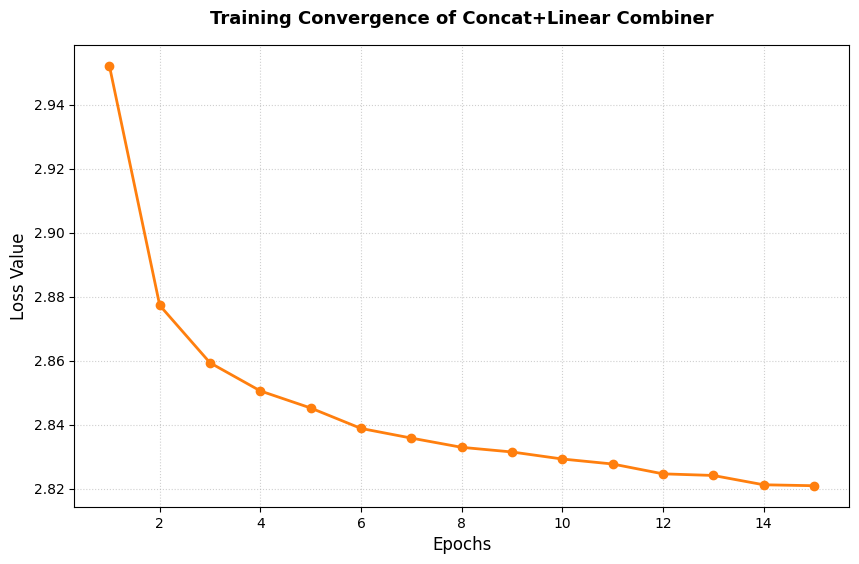

In [16]:
import os
import json
import time
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from pathlib import Path
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

# ============================================================ #
# 1. CẤU HÌNH & THIẾT BỊ                                       #
# ============================================================ #
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"[INFO] Đang sử dụng thiết bị: {DEVICE}")

# Thư mục chứa file JSON gốc
FIXED_OUTPUT_DIR = Path("/kaggle/working/fixed_test_data")
TRAIN_JSON_PATH = FIXED_OUTPUT_DIR / "fashion_train_combined_clean.json"

# Thư mục chứa file đặc trưng đã trích xuất từ bước trước
EXTRACTED_DIR = Path("/kaggle/working/extracted_features_distilled")

# Sửa lại đúng đường dẫn load file .pt
LOAD_IMAGE_FEATURES_PATH = EXTRACTED_DIR / "image_features_distilled.pt"
LOAD_TEXT_FEATURES_PATH = EXTRACTED_DIR / "text_features_distilled.pt"


# ============================================================ #
# 2. KIẾN TRÚC MẠNG CONCAT + LINEAR (SIÊU TỐI GIẢN)           #
# ============================================================ #
class ConcatLinearCombiner(nn.Module):
    """
    Bộ trộn tối giản nhất có thể: 
    Nối [Ảnh, Chữ] -> Nhân ma trận Linear -> Cộng ảnh gốc -> Chuẩn hóa.
    Không dùng lớp ẩn (hidden layers), không dùng hàm kích hoạt phi tuyến.
    """
    def __init__(self, dim=512):
        super().__init__()
        # Nén trực tiếp từ 1024 (512 Ảnh + 512 Chữ) về 512 chiều
        self.proj = nn.Linear(dim * 2, dim)
        self.layer_norm = nn.LayerNorm(dim)

    def forward(self, image_emb, text_emb):
        # 1. Nối chuỗi (Concatenate)
        merged = torch.cat([image_emb, text_emb], dim=-1)
        
        # 2. Ánh xạ tuyến tính (Linear Projection)
        out = self.proj(merged)
        
        # 3. Mạch thặng dư (Residual) để giữ bản sắc ảnh gốc
        out = self.layer_norm(out + image_emb) 
        
        return F.normalize(out, dim=-1)


# ============================================================ #
# 3. ĐỊNH NGHĨA HÀM LOSS INFONCE & DATASET                     #
# ============================================================ #
class InfoNCELoss(nn.Module):
    def __init__(self, temperature=0.07):
        super().__init__()
        self.temperature = temperature
        
    def forward(self, predicted_target, pos_emb):
        pos_emb = F.normalize(pos_emb, dim=-1)
        logits = torch.matmul(predicted_target, pos_emb.T) / self.temperature
        batch_size = predicted_target.size(0)
        labels = torch.arange(batch_size, device=predicted_target.device)
        return F.cross_entropy(logits, labels)

class SavedFeatureContrastiveDataset(Dataset):
    def __init__(self, image_features_dict, text_features_tensor, data_list):
        self.image_features = image_features_dict
        self.text_features = text_features_tensor
        self.data_list = data_list
        
    def __len__(self):
        return len(self.data_list)
        
    def __getitem__(self, idx):
        item = self.data_list[idx]
        return self.image_features[item["candidate"]], self.text_features[idx], self.image_features[item["target"]]


# ============================================================ #
# 4. NẠP DỮ LIỆU ĐẶC TRƯNG VÀO RAM                            #
# ============================================================ #
print("[INFO] Đang nạp dữ liệu...")
with open(TRAIN_JSON_PATH, "r", encoding="utf-8") as f:
    train_data = json.load(f)

image_features_dict = torch.load(LOAD_IMAGE_FEATURES_PATH, map_location="cpu")
text_features_tensor = torch.load(LOAD_TEXT_FEATURES_PATH, map_location="cpu")


# ============================================================ #
# 5. TIẾN HÀNH HUẤN LUYỆN MẠNG LINEAR                          #
# ============================================================ #
train_dataset = SavedFeatureContrastiveDataset(image_features_dict, text_features_tensor, train_data)
train_loader = DataLoader(train_dataset, batch_size=512, shuffle=True, drop_last=True)

# Khởi tạo mô hình
combiner = ConcatLinearCombiner(dim=512).to(DEVICE)
criterion = InfoNCELoss(temperature=0.07)
# Tăng weight_decay một chút để ma trận Linear mượt mà
optimizer = torch.optim.AdamW(combiner.parameters(), lr=1e-3, weight_decay=1e-2)

epochs = 15 # Cực kỳ đơn giản nên 30 epochs là đủ hội tụ
loss_history = []

print(f"\n[START] Bắt đầu huấn luyện Concat+Linear Combiner trong {epochs} Epochs...")

for epoch in range(epochs):
    combiner.train()
    epoch_loss = 0.0
    start_time = time.time()
    
    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}")
    for cand_emb, text_emb, pos_emb in pbar:
        cand_emb, text_emb, pos_emb = cand_emb.to(DEVICE), text_emb.to(DEVICE), pos_emb.to(DEVICE)
        
        optimizer.zero_grad()
        predicted_target = combiner(cand_emb, text_emb)
        loss = criterion(predicted_target, pos_emb)
        
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item()
        pbar.set_postfix({"Loss": f"{loss.item():.4f}"})
        
    avg_loss = epoch_loss / len(train_loader)
    loss_history.append(avg_loss)
    elapsed_time = time.time() - start_time
    print(f"-> Epoch {epoch+1:02d}/{epochs:02d} | Loss: {avg_loss:.4f} | Thời gian: {elapsed_time:.1f}s")

# Lưu checkpoint
combiner_save_path = FIXED_OUTPUT_DIR / "concat_linear_pure_infonce_best.pt"
torch.save(combiner.state_dict(), combiner_save_path)
print(f"\n[DONE] Đã lưu mô hình Concat+Linear tại: {combiner_save_path}")

# Vẽ đồ thị
plt.figure(figsize=(10, 6))
plt.plot(range(1, epochs + 1), loss_history, marker='o', linestyle='-', color='#ff7f0e', linewidth=2)
plt.title('Training Convergence of Concat+Linear Combiner', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss Value', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)
plt.savefig(FIXED_OUTPUT_DIR / "concat_linear_loss_curve.png", dpi=300)
plt.show()

# Đánh giá ConCat+Linear của mô hình baseline

In [17]:
import os
import json
import torch
import torch.nn as nn
import torch.nn.functional as F
from pathlib import Path
import numpy as np
from tqdm.auto import tqdm
from PIL import Image
from transformers import CLIPModel, CLIPProcessor
from transformers import logging as transformers_logging

transformers_logging.set_verbosity_error()

# ============================================================ #
# 1. CẤU HÌNH ĐƯỜNG DẪN & THIẾT BỊ                             #
# ============================================================ #
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"[INFO] Đang sử dụng thiết bị để đánh giá: {DEVICE}")

FASHION_ROOT = Path("/kaggle/input/datasets/mayukh18/fashion200k-dataset")
FIXED_OUTPUT_DIR = Path("/kaggle/working/fixed_test_data")
TEST_JSON_PATH = FIXED_OUTPUT_DIR / "fashion_test_combined_clean.json" 

# Trọng số của mô hình FashionCLIP đã fine-tune tiếng Việt
FASHION_CLIP_NAME = "patrickjohncyh/fashion-clip"
FASHION_CLIP_DISTILLED_PT = "/kaggle/input/datasets/npnam0123/fashionclip-nophobert/clip_direct_epoch_3.pt"

# Trọng số của mạng Concat+Linear
COMBINER_PT = FIXED_OUTPUT_DIR / "concat_linear_pure_infonce_best.pt"  
MAX_LENGTH = 77


# ============================================================ #
# 2. KHAI BÁO KIẾN TRÚC MẠNG CONCAT + LINEAR                  #
# ============================================================ #
class ConcatLinearCombiner(nn.Module):
    def __init__(self, dim=512):
        super().__init__()
        self.proj = nn.Linear(dim * 2, dim)
        self.layer_norm = nn.LayerNorm(dim)

    def forward(self, image_emb, text_emb):
        merged = torch.cat([image_emb, text_emb], dim=-1)
        out = self.proj(merged)
        out = self.layer_norm(out + image_emb) 
        return F.normalize(out, dim=-1)


# ============================================================ #
# 3. NẠP MÔ HÌNH VÀ DỮ LIỆU KIỂM THỬ                          #
# ============================================================ #
print("\n[INFO] Đang nạp mô hình FashionCLIP Distilled và Concat+Linear...")

clip_processor = CLIPProcessor.from_pretrained(FASHION_CLIP_NAME)
clip_model = CLIPModel.from_pretrained(FASHION_CLIP_NAME).to(DEVICE)

# Nạp trọng số FashionCLIP đã chưng cất
checkpoint = torch.load(FASHION_CLIP_DISTILLED_PT, map_location=DEVICE)
state_dict = checkpoint["model_state_dict"] if "model_state_dict" in checkpoint else checkpoint
clip_model.load_state_dict(state_dict, strict=False)
clip_model.eval()
print("[LOAD SUCCESS] Đã nạp thành công FashionCLIP Distilled!")

combiner = ConcatLinearCombiner(dim=512).to(DEVICE)
combiner.load_state_dict(torch.load(COMBINER_PT, map_location=DEVICE))
combiner.eval()
print("[LOAD SUCCESS] Đã nạp thành công ConcatLinearCombiner!")

with open(TEST_JSON_PATH, "r", encoding="utf-8") as f:
    test_data = json.load(f)
print(f"[INFO] Tổng số lượng mẫu Test: {len(test_data)}")


# ============================================================ #
# 4. TRÍCH XUẤT ĐẶC TRƯNG ẢNH (CANDIDATE & TARGET) VÀ VĂN BẢN  #
# ============================================================ #
# Gộp chung Candidate và Target để trích xuất ảnh 1 lần duy nhất cho tối ưu
unique_test_images = list(set([item["candidate"] for item in test_data] + [item["target"] for item in test_data]))
image_features_dict = {}

print("\n[INFO] Đang trích xuất đặc trưng Ảnh (Safe Tensor Extraction)...")
with torch.no_grad():
    for i in tqdm(range(0, len(unique_test_images), 128), desc="Images"):
        batch_paths = unique_test_images[i:i+128]
        images, valid_paths = [], []
        for p in batch_paths:
            full_p = FASHION_ROOT / p
            if full_p.exists():
                try:
                    images.append(Image.open(full_p).convert("RGB"))
                    valid_paths.append(p)
                except Exception:
                    pass
        if not images: continue
        
        inputs = clip_processor(images=images, return_tensors="pt").to(DEVICE)
        img_outputs = clip_model.get_image_features(**inputs)
        
        # Safe Tensor Extraction
        if torch.is_tensor(img_outputs): img_embs = img_outputs
        elif hasattr(img_outputs, "image_embeds") and img_outputs.image_embeds is not None: img_embs = img_outputs.image_embeds
        elif hasattr(img_outputs, "pooler_output"):
            img_embs = img_outputs.pooler_output
            if hasattr(clip_model, "visual_projection") and img_embs.shape[-1] != clip_model.config.projection_dim:
                img_embs = clip_model.visual_projection(img_embs)
        else: img_embs = img_outputs[0]
            
        if img_embs.dim() == 3: img_embs = img_embs[:, 0, :]
        img_embs = F.normalize(img_embs, dim=-1).cpu()
        
        for p, emb in zip(valid_paths, img_embs): 
            image_features_dict[p] = emb

text_features_list = []
print("\n[INFO] Đang trích xuất đặc trưng Văn bản (Safe Tensor Extraction)...")
with torch.no_grad():
    for i in tqdm(range(0, len(test_data), 128), desc="Texts"):
        batch_items = test_data[i:i+128]
        raw_captions = [item.get("captions_vi", item.get("text_vi", [""]))[0] for item in batch_items]
        
        inputs = clip_processor(text=raw_captions, padding="max_length", truncation=True, max_length=MAX_LENGTH, return_tensors="pt").to(DEVICE)
        txt_outputs = clip_model.get_text_features(input_ids=inputs["input_ids"], attention_mask=inputs["attention_mask"])
        
        # Safe Tensor Extraction
        if torch.is_tensor(txt_outputs): txt_embs = txt_outputs
        elif hasattr(txt_outputs, "text_embeds") and txt_outputs.text_embeds is not None: txt_embs = txt_outputs.text_embeds
        elif hasattr(txt_outputs, "pooler_output"):
            txt_embs = txt_outputs.pooler_output
            if hasattr(clip_model, "text_projection") and txt_embs.shape[-1] != clip_model.config.projection_dim:
                txt_embs = clip_model.text_projection(txt_embs)
        else: txt_embs = txt_outputs[0]
            
        if txt_embs.dim() == 3: txt_embs = txt_embs[:, 0, :]
        txt_embs = F.normalize(txt_embs, dim=-1).cpu()
        
        text_features_list.extend(txt_embs)

text_features_tensor = torch.stack(text_features_list)

# Giải phóng mô hình nặng
del clip_model
torch.cuda.empty_cache()


# ============================================================ #
# 5. KHỞI TẠO TẬP GALLERY VÀ TÍNH TOÁN METRICS                 #
# ============================================================ #
gallery_paths = list(set([item["target"] for item in test_data if item["target"] in image_features_dict]))
gallery_tensor = torch.stack([image_features_dict[p] for p in gallery_paths]).to(DEVICE)
gallery_path_to_idx = {path: idx for idx, path in enumerate(gallery_paths)}

print(f"\n[INFO] Đang tính toán Metrics với Kho Gallery ({len(gallery_paths)} ảnh đích)...")
def calculate_recall(ranks, k):
    return 100.0 * np.sum(ranks < k) / len(ranks)

valid_test_indices = [idx for idx, item in enumerate(test_data) if item["candidate"] in image_features_dict and item["target"] in image_features_dict]

ranks_list = []
EVAL_BATCH_SIZE = 256

with torch.no_grad():
    for i in tqdm(range(0, len(valid_test_indices), EVAL_BATCH_SIZE), desc="Evaluating Combiner"):
        batch_idxs = valid_test_indices[i : i + EVAL_BATCH_SIZE]
        
        batch_cand_embs = torch.stack([image_features_dict[test_data[idx]["candidate"]] for idx in batch_idxs]).to(DEVICE)
        batch_text_embs = text_features_tensor[batch_idxs].to(DEVICE)
        
        # Đưa qua mạng ConcatLinearCombiner
        predicted_embs = combiner(batch_cand_embs, batch_text_embs) 
        
        # Tính khoảng cách và xếp hạng
        similarities = torch.matmul(predicted_embs, gallery_tensor.T)
        sorted_indices = torch.argsort(similarities, descending=True, dim=-1).cpu().numpy()
        
        for j, idx in enumerate(batch_idxs):
            targ_path = test_data[idx]["target"]
            correct_target_idx = gallery_path_to_idx[targ_path]
            rank = np.where(sorted_indices[j] == correct_target_idx)[0][0]
            ranks_list.append(rank)

ranks_array = np.array(ranks_list)
r1 = calculate_recall(ranks_array, 1)
r5 = calculate_recall(ranks_array, 5)
r10 = calculate_recall(ranks_array, 10)
r50 = calculate_recall(ranks_array, 50)
mean_rank = np.mean(ranks_array) + 1 

print("\n" + "="*50)
print(f"🚀 KẾT QUẢ ĐÁNH GIÁ (CONCAT + LINEAR) 🚀")
print("="*50)
print(f"Tổng số truy vấn hợp lệ : {len(ranks_list)}")
print(f"Kích thước tập Gallery  : {len(gallery_paths)} ảnh đích")
print(f"Recall@1                : {r1:.2f}%")
print(f"Recall@5                : {r5:.2f}%")
print(f"Recall@10               : {r10:.2f}%")
print(f"Recall@50               : {r50:.2f}%")
print(f"Mean Rank (Thứ hạng TB) : {mean_rank:.2f}")
print("="*50)

[INFO] Đang sử dụng thiết bị để đánh giá: cuda

[INFO] Đang nạp mô hình FashionCLIP Distilled và Concat+Linear...


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

[LOAD SUCCESS] Đã nạp thành công FashionCLIP Distilled!
[LOAD SUCCESS] Đã nạp thành công ConcatLinearCombiner!
[INFO] Tổng số lượng mẫu Test: 5000

[INFO] Đang trích xuất đặc trưng Ảnh (Safe Tensor Extraction)...


Images:   0%|          | 0/71 [00:00<?, ?it/s]


[INFO] Đang trích xuất đặc trưng Văn bản (Safe Tensor Extraction)...


Texts:   0%|          | 0/40 [00:00<?, ?it/s]


[INFO] Đang tính toán Metrics với Kho Gallery (4545 ảnh đích)...


Evaluating Combiner:   0%|          | 0/20 [00:00<?, ?it/s]


🚀 KẾT QUẢ ĐÁNH GIÁ (CONCAT + LINEAR) 🚀
Tổng số truy vấn hợp lệ : 5000
Kích thước tập Gallery  : 4545 ảnh đích
Recall@1                : 8.68%
Recall@5                : 27.72%
Recall@10               : 40.24%
Recall@50               : 70.94%
Mean Rank (Thứ hạng TB) : 73.28


# Huấn luyện MLP Cho PHoBERT(Freeze)

[INFO] Đang sử dụng thiết bị: cuda
[INFO] Đang nạp các file đặc trưng precomputed từ ổ đĩa...
[SUCCESS] Đã nạp 182410 ảnh và 180136 vector chữ vào RAM!

[START] Bắt đầu huấn luyện mạng MLP Combiner với InfoNCE Loss trong 15 Epochs...


Epoch 1/15:   0%|          | 0/351 [00:00<?, ?it/s]

-> Epoch 1/15 | InfoNCE Training Loss: 2.8931



Epoch 2/15:   0%|          | 0/351 [00:00<?, ?it/s]

-> Epoch 2/15 | InfoNCE Training Loss: 2.5807



...

-> Epoch 13/15 | InfoNCE Training Loss: 2.2193



Epoch 14/15:   0%|          | 0/351 [00:00<?, ?it/s]

-> Epoch 14/15 | InfoNCE Training Loss: 2.2055



Epoch 15/15:   0%|          | 0/351 [00:00<?, ?it/s]

-> Epoch 15/15 | InfoNCE Training Loss: 2.1902

[DONE] Đã lưu mô hình tại: /kaggle/working/fixed_test_data/mlp_combiner_infonce.pt
[INFO] Đang vẽ biểu đồ học tập của mạng MLP...
[DONE] Biểu đồ hoàn tất! Đã lưu tại: /kaggle/working/fixed_test_data/mlp_infonce_loss_curve.png


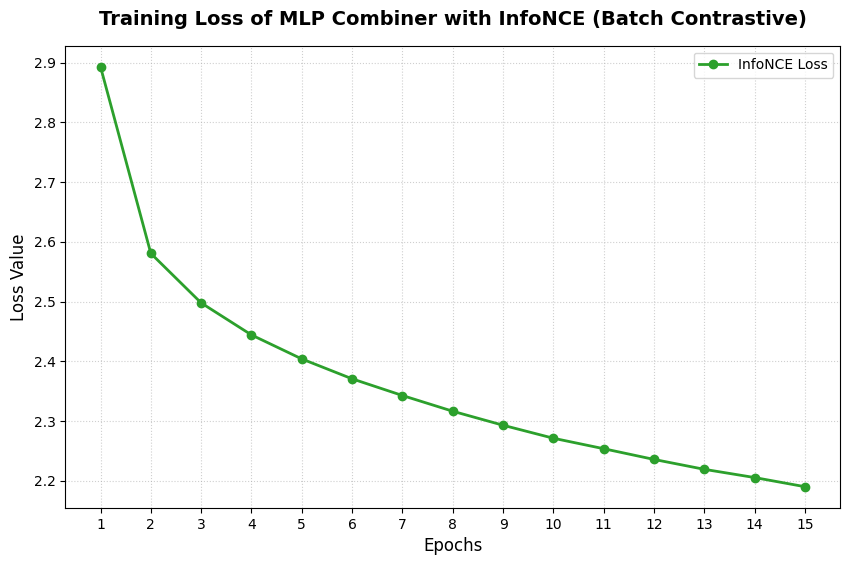

In [6]:
import os
import json
import time
import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from pathlib import Path
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

# ============================================================ #
# 1. CẤU HÌNH & THIẾT BỊ                                       #
# ============================================================ #
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"[INFO] Đang sử dụng thiết bị: {DEVICE}")

FIXED_OUTPUT_DIR = Path("/kaggle/working/fixed_test_data")
TRAIN_JSON_PATH = FIXED_OUTPUT_DIR / "fashion_train_combined_clean.json"

# Đường dẫn tới 2 file đặc trưng .pt đã lưu ở bước trước
LOAD_IMAGE_FEATURES_PATH = FIXED_OUTPUT_DIR / "image_features_precomputed.pt"
LOAD_TEXT_FEATURES_PATH = FIXED_OUTPUT_DIR / "text_features_precomputed.pt"

# ============================================================ #
# 2. KIẾN TRÚC MẠNG MLP COMBINER (BASELINE)                    #
# ============================================================ #
class MLPCombiner(nn.Module):
    def __init__(self, input_dim=512, hidden_dim=1024, output_dim=512):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(input_dim * 2, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.3),
            
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.BatchNorm1d(hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(0.2),
            
            nn.Linear(hidden_dim // 2, output_dim)
        )
        
    def forward(self, image_emb, text_emb):
        x = torch.cat([image_emb, text_emb], dim=-1)
        out = self.mlp(x)
        return F.normalize(out, dim=-1)


# ============================================================ #
# 3. ĐỊNH NGHĨA HÀM LOSS INFONCE & DATASET NÂNG CẤP            #
# ============================================================ #
class InfoNCELoss(nn.Module):
    """
    Hàm loss Contrastive dựa trên Batch (InfoNCE).
    Ép ma trận dự đoán phải trùng khớp với ma trận mục tiêu trên đường chéo chính,
    đồng thời đẩy xa tất cả các mẫu khác xuất hiện trong cùng một Batch.
    """
    def __init__(self, temperature=0.07):
        super().__init__()
        self.temperature = temperature
        
    def forward(self, predicted_target, pos_emb):
        # Đảm bảo các vector mục tiêu cũng đã được chuẩn hóa L2
        pos_emb = F.normalize(pos_emb, dim=-1)
        
        # Tính toán ma trận tương đồng giữa các mẫu trong Batch: [Batch_Size, Batch_Size]
        # Mỗi hàng i đại diện cho điểm tương đồng của truy vấn i với tất cả ảnh đích j trong batch
        logits = torch.matmul(predicted_target, pos_emb.T) / self.temperature
        
        # Nhãn đúng (Ground Truth) chính là vị trí đường chéo chính (i == j)
        batch_size = predicted_target.size(0)
        labels = torch.arange(batch_size, device=predicted_target.device)
        
        # Sử dụng Cross Entropy để tối ưu hóa đồng thời lực hút đường chéo và lực đẩy xung quanh
        loss = F.cross_entropy(logits, labels)
        return loss

class SavedFeatureContrastiveDataset(Dataset):
    """ Dataset rút gọn: Không cần bốc mẫu Negative ngẫu nhiên nữa """
    def __init__(self, image_features_dict, text_features_tensor, data_list):
        self.image_features = image_features_dict
        self.text_features = text_features_tensor
        self.data_list = data_list
        
    def __len__(self):
        return len(self.data_list)
        
    def __getitem__(self, idx):
        item = self.data_list[idx]
        cand_path = item["candidate"]
        targ_path = item["target"]
        
        cand_emb = self.image_features[cand_path]
        pos_emb = self.image_features[targ_path]
        text_emb = self.text_features[idx]
        
        return cand_emb, text_emb, pos_emb


# ============================================================ #
# 4. NẠP DỮ LIỆU ĐẶC TRƯNG ĐÃ TÍNH TOÁN TRƯỚC                  #
# ============================================================ #
print("[INFO] Đang nạp các file đặc trưng precomputed từ ổ đĩa...")
with open(TRAIN_JSON_PATH, "r", encoding="utf-8") as f:
    train_data = json.load(f)

image_features_dict = torch.load(LOAD_IMAGE_FEATURES_PATH, map_location="cpu")
text_features_tensor = torch.load(LOAD_TEXT_FEATURES_PATH, map_location="cpu")

print(f"[SUCCESS] Đã nạp {len(image_features_dict)} ảnh và {text_features_tensor.shape[0]} vector chữ vào RAM!")


# ============================================================ #
# 5. TIẾN HÀNH HUẤN LUYỆN MẠNG MLP VỚI INFONCE LOSS            #
# ============================================================ #
train_dataset = SavedFeatureContrastiveDataset(image_features_dict, text_features_tensor, train_data)

# CHÚ Ý: Bắt buộc phải đặt drop_last=True để kích thước ma trận vuông [512, 512] đồng nhất ở batch cuối
train_loader = DataLoader(train_dataset, batch_size=512, shuffle=True, drop_last=True)

mlp_model = MLPCombiner(input_dim=512, hidden_dim=1024, output_dim=512).to(DEVICE)
criterion = InfoNCELoss(temperature=0.07)
optimizer = torch.optim.AdamW(mlp_model.parameters(), lr=1e-3, weight_decay=1e-4)

epochs = 15
mlp_loss_history = []

print(f"\n[START] Bắt đầu huấn luyện mạng MLP Combiner với InfoNCE Loss trong {epochs} Epochs...")
for epoch in range(epochs):
    mlp_model.train()
    epoch_loss = 0.0
    
    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}")
    for cand_emb, text_emb, pos_emb in pbar:
        cand_emb = cand_emb.to(DEVICE)
        text_emb = text_emb.to(DEVICE)
        pos_emb = pos_emb.to(DEVICE)
        
        optimizer.zero_grad()
        
        # Lấy vector dự đoán của bộ trộn
        predicted_target = mlp_model(cand_emb, text_emb)
        
        # Tính toán InfoNCE Loss (1 mẫu đúng đấu chọi với 511 mẫu sai trong batch)
        loss = criterion(predicted_target, pos_emb)
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item()
        pbar.set_postfix({"loss": f"{loss.item():.4f}"})
        
    avg_loss = epoch_loss / len(train_loader)
    mlp_loss_history.append(avg_loss)
    print(f"-> Epoch {epoch+1}/{epochs} | InfoNCE Training Loss: {avg_loss:.4f}\n")

# Lưu trọng số của mạng MLP sau khi train với hàm Loss mới
mlp_save_path = FIXED_OUTPUT_DIR / "mlp_combiner_infonce.pt"
torch.save(mlp_model.state_dict(), mlp_save_path)
print(f"[DONE] Đã lưu mô hình tại: {mlp_save_path}")


# ============================================================ #
# 6. VẼ BIỂU ĐỒ LOSS ĐỂ ĐÁNH GIÁ MỨC ĐỘ HỘI TỤ                 #
# ============================================================ #
print("[INFO] Đang vẽ biểu đồ học tập của mạng MLP...")
plt.figure(figsize=(10, 6))
plt.plot(range(1, epochs + 1), mlp_loss_history, marker='o', linestyle='-', color='#2ca02c', linewidth=2, label='InfoNCE Loss')
plt.title('Training Loss of MLP Combiner with InfoNCE (Batch Contrastive)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss Value', fontsize=12)
plt.xticks(range(1, epochs + 1))
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()

plot_path = FIXED_OUTPUT_DIR / "mlp_infonce_loss_curve.png"
plt.savefig(plot_path, dpi=300, bbox_inches='tight')
print(f"[DONE] Biểu đồ hoàn tất! Đã lưu tại: {plot_path}")

plt.show()

# Đánh giá MLP Cho PHoBERT(Freeze )

In [8]:
import os
import json
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from pathlib import Path
import numpy as np
from tqdm.auto import tqdm
from PIL import Image
import py_vncorenlp
from transformers import AutoTokenizer, AutoModel, CLIPModel, CLIPProcessor
from transformers import logging as transformers_logging

# Ẩn các thông báo đỏ/cảnh báo không cần thiết từ Hugging Face
transformers_logging.set_verbosity_error()

# ============================================================ #
# 1. CẤU HÌNH ĐƯỜNG DẪN & THIẾT BỊ                             #
# ============================================================ #
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"[INFO] Đang sử dụng thiết bị: {DEVICE}")

FASHION_ROOT = Path("/kaggle/input/datasets/mayukh18/fashion200k-dataset")
FIXED_OUTPUT_DIR = Path("/kaggle/working/fixed_test_data")
FIXED_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Đường dẫn file dữ liệu Test JSON đầu vào
TEST_JSON_PATH = FIXED_OUTPUT_DIR / "fashion_test_combined_clean.json"

# Đường dẫn lưu trữ/nạp trọng số mô hình
PHOBERT_STUDENT_PT = "/kaggle/input/datasets/npnam0123/phobert-true/student_best (2).pt"
MLP_CHECKPOINT_PATH = FIXED_OUTPUT_DIR / "mlp_combiner_infonce.pt"
FASHION_CLIP_NAME = "patrickjohncyh/fashion-clip"

# Khởi tạo bộ tách từ tiếng Việt VnCoreNLP
if 'rdrsegmenter' not in globals():
    if not os.path.exists('/kaggle/working/VnCoreNLP-1.2.jar'):
        py_vncorenlp.download_model(save_dir='/kaggle/working')
    rdrsegmenter = py_vncorenlp.VnCoreNLP(annotators=["wseg"], save_dir='/kaggle/working')


# ============================================================ #
# 2. KHAI BÁO KIẾN TRÚC MÔ HÌNH (Khớp với quá trình Train)     #
# ============================================================ #
class PhoBERTFashionCLIPStudent(nn.Module):
    def __init__(self, phobert_name="vinai/phobert-base-v2", out_dim=512):
        super().__init__()
        self.encoder = AutoModel.from_pretrained(phobert_name)
        hidden_size = self.encoder.config.hidden_size
        self.projection = nn.Sequential(
            nn.Linear(hidden_size, hidden_size),
            nn.GELU(),
            nn.LayerNorm(hidden_size),
            nn.Dropout(0.1),
            nn.Linear(hidden_size, out_dim),
        )
        
    def load_state_dict_flexible(self, checkpoint_path, device):
        checkpoint = torch.load(checkpoint_path, map_location=device)
        state_dict = checkpoint["model_state_dict"] if "model_state_dict" in checkpoint else checkpoint
        new_state_dict = {k.replace("roberta.", "encoder.", 1) if k.startswith("roberta.") else k: v for k, v in state_dict.items()}
        self.load_state_dict(new_state_dict, strict=False)
        print(f"[LOAD SUCCESS] Đã nạp thành công PhoBERT Student!")

    def forward(self, input_ids, attention_mask):
        outputs = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        cls = outputs.last_hidden_state[:, 0, :]
        emb = self.projection(cls)
        return F.normalize(emb, dim=-1)


class MLPCombiner(nn.Module):
    def __init__(self, input_dim=512, hidden_dim=1024, output_dim=512):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(input_dim * 2, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.3),
            
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.BatchNorm1d(hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(0.2),
            
            nn.Linear(hidden_dim // 2, output_dim)
        )
        
    def forward(self, image_emb, text_emb):
        x = torch.cat([image_emb, text_emb], dim=-1)
        out = self.mlp(x)
        return F.normalize(out, dim=-1)


# ============================================================ #
# 3. NẠP MÔ HÌNH VÀ DỰ LIỆU                                    #
# ============================================================ #
print("\n[INFO] Đang khởi tạo các mô hình Encoders & MLP Combiner...")
tokenizer = AutoTokenizer.from_pretrained("vinai/phobert-base-v2")

text_encoder = PhoBERTFashionCLIPStudent().to(DEVICE)
text_encoder.load_state_dict_flexible(PHOBERT_STUDENT_PT, DEVICE)
text_encoder.eval()

clip_model = CLIPModel.from_pretrained(FASHION_CLIP_NAME).to(DEVICE)
clip_processor = CLIPProcessor.from_pretrained(FASHION_CLIP_NAME)
clip_model.eval()

mlp_model = MLPCombiner(input_dim=512, hidden_dim=1024, output_dim=512).to(DEVICE)
mlp_model.load_state_dict(torch.load(MLP_CHECKPOINT_PATH, map_location=DEVICE))
mlp_model.eval()

with open(TEST_JSON_PATH, "r", encoding="utf-8") as f:
    test_data = json.load(f)
print(f"[INFO] Tổng số lượng mẫu Test tìm thấy: {len(test_data)}")


# ============================================================ #
# 4. TRÍCH XUẤT TRỰC TIẾP ĐẶC TRƯNG TẬP TEST TRÊN RAM          #
# ============================================================ #
# --- A. Trích xuất đặc trưng Ảnh Tập Test ---
unique_test_images = set()
for item in test_data:
    unique_test_images.add(item["candidate"])
    unique_test_images.add(item["target"])
unique_test_images = list(unique_test_images)

image_features_dict = {}
print("\n[INFO] Đang trích xuất đặc trưng Ảnh tập Test qua FashionCLIP...")

with torch.no_grad():
    for i in tqdm(range(0, len(unique_test_images), 128), desc="Extracting Test Images"):
        batch_paths = unique_test_images[i:i+128]
        images = []
        valid_paths = []
        
        for p in batch_paths:
            full_p = FASHION_ROOT / p
            if full_p.exists():
                try:
                    images.append(Image.open(full_p).convert("RGB"))
                    valid_paths.append(p)
                except Exception:
                    continue
                
        if not images: 
            continue
            
        inputs = clip_processor(images=images, return_tensors="pt").to(DEVICE)
        img_outputs = clip_model.get_image_features(**inputs)
        
        if hasattr(img_outputs, "pooler_output") and img_outputs.pooler_output is not None:
            img_embs = img_outputs.pooler_output
        elif hasattr(img_outputs, "last_hidden_state"):
            img_embs = img_outputs.last_hidden_state[:, 0, :]
        else:
            img_embs = img_outputs
            
        img_embs = F.normalize(img_embs, dim=-1).cpu()
        
        for p, emb in zip(valid_paths, img_embs):
            image_features_dict[p] = emb

# --- B. Trích xuất đặc trưng Văn bản Tập Test ---
text_features_list = []
print("\n[INFO] Đang trích xuất đặc trưng Văn bản tiếng Việt tập Test qua PhoBERT Student...")

with torch.no_grad():
    for i in tqdm(range(0, len(test_data), 128), desc="Extracting Test Texts"):
        batch_items = test_data[i:i+128]
        captions_segmented = []
        
        for item in batch_items:
            raw_vi = item.get("captions_vi", item.get("text_vi", [""]))[0]
            seg_vi = rdrsegmenter.word_segment(raw_vi)[0]
            captions_segmented.append(seg_vi)
            
        inputs = tokenizer(captions_segmented, padding=True, truncation=True, max_length=128, return_tensors="pt").to(DEVICE)
        txt_embs = text_encoder(inputs["input_ids"], inputs["attention_mask"]).cpu()
        
        for emb in txt_embs:
            text_features_list.append(emb)

text_features_tensor = torch.stack(text_features_list)

# Giải phóng bộ nhớ của Encoders cồng kềnh để tránh tràn VRAM
del clip_model, text_encoder
torch.cuda.empty_cache()


# ============================================================ #
# 5. KHỞI TẠO KHO ẢNH GALLERY TÌM KIẾM (TARGET GALLERY)         #
# ============================================================ #
# Tập hợp toàn bộ ảnh Target độc nhất hợp lệ
gallery_paths = list(set([item["target"] for item in test_data if item["target"] in image_features_dict]))
gallery_tensor = torch.stack([image_features_dict[p] for p in gallery_paths]).to(DEVICE)

print(f"\n[INFO] Khởi tạo kho ảnh Gallery gồm: {len(gallery_paths)} ảnh.")


# ============================================================ #
# 6. TIẾN HÀNH ĐÁNH GIÁ (INFERENCE & METRICS - OPTIMIZED)      #
# ============================================================ #
def calculate_recall(ranks, k):
    return 100.0 * np.sum(ranks < k) / len(ranks)

# TỐI ƯU 1: Ánh xạ cấu trúc dữ liệu Map O(1) để loại bỏ hàm liệt kê .index() chậm chạp
gallery_path_to_idx = {path: idx for idx, path in enumerate(gallery_paths)}

ranks_list = []

# Lọc trước các chỉ mục (Index) dữ liệu hợp lệ để tránh lệch pha với `text_features_tensor`
valid_test_indices = []
for idx, item in enumerate(test_data):
    if item["candidate"] in image_features_dict and item["target"] in image_features_dict:
        valid_test_indices.append(idx)

print(f"\n[INFO] Số lượng mẫu kiểm thử hợp lệ sau bộ lọc: {len(valid_test_indices)}/{len(test_data)}")
print("[INFO] Đang tiến hành tính toán song song ma trận tương đồng trên GPU theo Batch...")

# TỐI ƯU 2: Gom cụm xử lý Batch (Kích thước 256) thay vì chạy vòng lặp từng ảnh một
EVAL_BATCH_SIZE = 256
mlp_model.eval()

with torch.no_grad():
    for i in tqdm(range(0, len(valid_test_indices), EVAL_BATCH_SIZE), desc="Evaluating MLP"):
        batch_idxs = valid_test_indices[i : i + EVAL_BATCH_SIZE]
        
        # Gom cụm các vector đặc trưng đầu vào tương ứng cho Batch hiện tại
        batch_cand_embs = torch.stack([image_features_dict[test_data[idx]["candidate"]] for idx in batch_idxs]).to(DEVICE)
        batch_text_embs = text_features_tensor[batch_idxs].to(DEVICE)
        
        # Dự đoán đồng loạt vị trí vector Target lý tưởng qua mô hình mạng MLP
        predicted_target_embs = mlp_model(batch_cand_embs, batch_text_embs)  # Kích thước: [Batch_Size, 512]
        
        # Tính toán ma trận khoảng cách Cosine đồng thời giữa Batch dự đoán với Kho ảnh Gallery
        # [Batch_Size, 512] x [512, Num_Gallery] -> Ma trận kết quả: [Batch_Size, Num_Gallery]
        similarities = torch.matmul(predicted_target_embs, gallery_tensor.T)
        
        # Sắp xếp chỉ mục điểm số giảm dần theo từng hàng riêng biệt
        sorted_indices = torch.argsort(similarities, descending=True, dim=-1).cpu().numpy()
        
        # Duyệt qua các kết quả trong Batch để xác định thứ hạng (Rank) đúng
        for j, idx in enumerate(batch_idxs):
            targ_path = test_data[idx]["target"]
            correct_target_idx = gallery_path_to_idx[targ_path]  # Truy xuất siêu tốc với O(1)
            
            # Tìm kiếm vị trí xếp hạng thực tế của ảnh đích chuẩn xác
            rank = np.where(sorted_indices[j] == correct_target_idx)[0][0]
            ranks_list.append(rank)

# Thống kê kết quả độ đo cuối cùng
ranks_array = np.array(ranks_list)
r1 = calculate_recall(ranks_array, 1)
r5 = calculate_recall(ranks_array, 5)
r10 = calculate_recall(ranks_array, 10)
r50 = calculate_recall(ranks_array, 50)
mean_rank = np.mean(ranks_array) + 1


# ============================================================ #
# 7. HIỂN THỊ KẾT QUẢ ĐÁNH GIÁ                                 #
# ============================================================ #
print("\n" + "="*50)
print(f"📊 KẾT QUẢ ĐÁNH GIÁ MẠNG MLP TẬP TEST (ĐẦY ĐỦ) 📊")
print("="*50)
print(f"• Tổng số mẫu test hợp lệ       : {len(ranks_list)}")
print(f"• Kích thước tập Gallery        : {len(gallery_paths)} ảnh")
print(f"• Recall@1                      : {r1:.2f}%")
print(f"• Recall@5                      : {r5:.2f}%")
print(f"• Recall@10                     : {r10:.2f}%")
print(f"• Recall@50                     : {r50:.2f}%")
print(f"• Mean Rank (Thứ hạng trung bình): {mean_rank:.2f}")
print("="*50)

[INFO] Đang sử dụng thiết bị: cuda

[INFO] Đang khởi tạo các mô hình Encoders & MLP Combiner...


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[LOAD SUCCESS] Đã nạp thành công PhoBERT Student!


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

[INFO] Tổng số lượng mẫu Test tìm thấy: 5000

[INFO] Đang trích xuất đặc trưng Ảnh tập Test qua FashionCLIP...


...


[INFO] Đang trích xuất đặc trưng Văn bản tiếng Việt tập Test qua PhoBERT Student...


Extracting Test Texts:   0%|          | 0/40 [00:00<?, ?it/s]


[INFO] Khởi tạo kho ảnh Gallery gồm: 4545 ảnh.

[INFO] Số lượng mẫu kiểm thử hợp lệ sau bộ lọc: 5000/5000
[INFO] Đang tiến hành tính toán song song ma trận tương đồng trên GPU theo Batch...


Evaluating MLP:   0%|          | 0/20 [00:00<?, ?it/s]


📊 KẾT QUẢ ĐÁNH GIÁ MẠNG MLP TẬP TEST (ĐẦY ĐỦ) 📊
• Tổng số mẫu test hợp lệ       : 5000
• Kích thước tập Gallery        : 4545 ảnh
• Recall@1                      : 16.88%
• Recall@5                      : 42.92%
• Recall@10                     : 56.44%
• Recall@50                     : 84.66%
• Mean Rank (Thứ hạng trung bình): 34.82


# Huấn luyện ConCat+Linear PhoBERT(Freeze)

[INFO] Đang sử dụng thiết bị huấn luyện Concat+Linear: cuda
[INFO] Đang nạp dữ liệu...
The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.

[START] Bắt đầu huấn luyện Concat+Linear Combiner trong 15 Epochs...


Epoch 1/15:   0%|          | 0/351 [00:00<?, ?it/s]

-> Epoch 01/15 | Loss: 2.7460 | Thời gian: 2.9s


Epoch 2/15:   0%|          | 0/351 [00:00<?, ?it/s]

-> Epoch 02/15 | Loss: 2.6221 | Thời gian: 2.9s


...

-> Epoch 13/15 | Loss: 2.5332 | Thời gian: 2.9s


Epoch 14/15:   0%|          | 0/351 [00:00<?, ?it/s]

-> Epoch 14/15 | Loss: 2.5322 | Thời gian: 2.9s


Epoch 15/15:   0%|          | 0/351 [00:00<?, ?it/s]

-> Epoch 15/15 | Loss: 2.5294 | Thời gian: 2.9s

[DONE] Đã lưu mô hình Concat+Linear tại: /kaggle/working/fixed_test_data/concat_linear_pure_infonce_best.pt


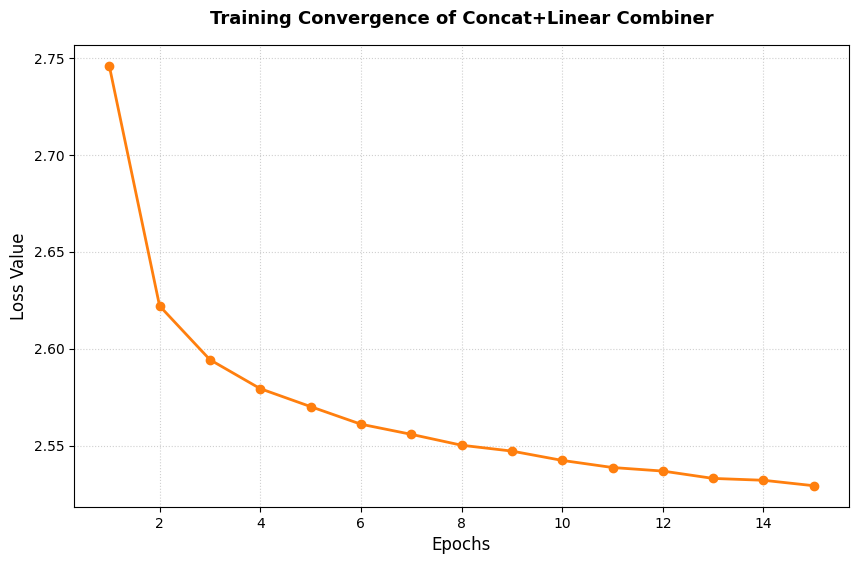

In [9]:
import os
import json
import time
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from pathlib import Path
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

# ============================================================ #
# 1. CẤU HÌNH ĐƯỜNG DẪN & THIẾT BỊ                            #
# ============================================================ #
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"[INFO] Đang sử dụng thiết bị huấn luyện Concat+Linear: {DEVICE}")

FIXED_OUTPUT_DIR = Path("/kaggle/working/fixed_test_data")
FIXED_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
TRAIN_JSON_PATH = FIXED_OUTPUT_DIR / "fashion_train_combined_clean.json"

LOAD_IMAGE_FEATURES_PATH = FIXED_OUTPUT_DIR / "image_features_precomputed.pt"
LOAD_TEXT_FEATURES_PATH = FIXED_OUTPUT_DIR / "text_features_precomputed.pt"


# ============================================================ #
# 2. KIẾN TRÚC MẠNG CONCAT + LINEAR (SIÊU TỐI GIẢN)           #
# ============================================================ #
class ConcatLinearCombiner(nn.Module):
    """
    Bộ trộn tối giản nhất có thể: 
    Nối [Ảnh, Chữ] -> Nhân ma trận Linear -> Cộng ảnh gốc -> Chuẩn hóa.
    Không dùng lớp ẩn (hidden layers), không dùng hàm kích hoạt phi tuyến.
    """
    def __init__(self, dim=512):
        super().__init__()
        # Nén trực tiếp từ 1024 (512 Ảnh + 512 Chữ) về 512 chiều
        self.proj = nn.Linear(dim * 2, dim)
        self.layer_norm = nn.LayerNorm(dim)

    def forward(self, image_emb, text_emb):
        # 1. Nối chuỗi (Concatenate)
        merged = torch.cat([image_emb, text_emb], dim=-1)
        
        # 2. Ánh xạ tuyến tính (Linear Projection)
        out = self.proj(merged)
        
        # 3. Mạch thặng dư (Residual) để giữ bản sắc ảnh gốc
        out = self.layer_norm(out + image_emb) 
        
        return F.normalize(out, dim=-1)


# ============================================================ #
# 3. ĐỊNH NGHĨA HÀM LOSS INFONCE & DATASET                     #
# ============================================================ #
class InfoNCELoss(nn.Module):
    def __init__(self, temperature=0.07):
        super().__init__()
        self.temperature = temperature
        
    def forward(self, predicted_target, pos_emb):
        pos_emb = F.normalize(pos_emb, dim=-1)
        logits = torch.matmul(predicted_target, pos_emb.T) / self.temperature
        batch_size = predicted_target.size(0)
        labels = torch.arange(batch_size, device=predicted_target.device)
        return F.cross_entropy(logits, labels)

class SavedFeatureContrastiveDataset(Dataset):
    def __init__(self, image_features_dict, text_features_tensor, data_list):
        self.image_features = image_features_dict
        self.text_features = text_features_tensor
        self.data_list = data_list
        
    def __len__(self):
        return len(self.data_list)
        
    def __getitem__(self, idx):
        item = self.data_list[idx]
        return self.image_features[item["candidate"]], self.text_features[idx], self.image_features[item["target"]]


# ============================================================ #
# 4. NẠP DỮ LIỆU ĐẶC TRƯNG VÀO RAM                            #
# ============================================================ #
print("[INFO] Đang nạp dữ liệu...")
with open(TRAIN_JSON_PATH, "r", encoding="utf-8") as f:
    train_data = json.load(f)

image_features_dict = torch.load(LOAD_IMAGE_FEATURES_PATH, map_location="cpu")
text_features_tensor = torch.load(LOAD_TEXT_FEATURES_PATH, map_location="cpu")


# ============================================================ #
# 5. TIẾN HÀNH HUẤN LUYỆN MẠNG LINEAR                          #
# ============================================================ #
train_dataset = SavedFeatureContrastiveDataset(image_features_dict, text_features_tensor, train_data)
train_loader = DataLoader(train_dataset, batch_size=512, shuffle=True, drop_last=True)

# Khởi tạo mô hình
combiner = ConcatLinearCombiner(dim=512).to(DEVICE)
criterion = InfoNCELoss(temperature=0.07)
# Tăng weight_decay một chút để ma trận Linear mượt mà
optimizer = torch.optim.AdamW(combiner.parameters(), lr=1e-3, weight_decay=1e-2)

epochs = 15 # Cực kỳ đơn giản nên 30 epochs là đủ hội tụ
loss_history = []

print(f"\n[START] Bắt đầu huấn luyện Concat+Linear Combiner trong {epochs} Epochs...")

for epoch in range(epochs):
    combiner.train()
    epoch_loss = 0.0
    start_time = time.time()
    
    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}")
    for cand_emb, text_emb, pos_emb in pbar:
        cand_emb, text_emb, pos_emb = cand_emb.to(DEVICE), text_emb.to(DEVICE), pos_emb.to(DEVICE)
        
        optimizer.zero_grad()
        predicted_target = combiner(cand_emb, text_emb)
        loss = criterion(predicted_target, pos_emb)
        
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item()
        pbar.set_postfix({"Loss": f"{loss.item():.4f}"})
        
    avg_loss = epoch_loss / len(train_loader)
    loss_history.append(avg_loss)
    elapsed_time = time.time() - start_time
    print(f"-> Epoch {epoch+1:02d}/{epochs:02d} | Loss: {avg_loss:.4f} | Thời gian: {elapsed_time:.1f}s")

# Lưu checkpoint
combiner_save_path = FIXED_OUTPUT_DIR / "concat_linear_pure_infonce_best.pt"
torch.save(combiner.state_dict(), combiner_save_path)
print(f"\n[DONE] Đã lưu mô hình Concat+Linear tại: {combiner_save_path}")

# Vẽ đồ thị
plt.figure(figsize=(10, 6))
plt.plot(range(1, epochs + 1), loss_history, marker='o', linestyle='-', color='#ff7f0e', linewidth=2)
plt.title('Training Convergence of Concat+Linear Combiner', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss Value', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)
plt.savefig(FIXED_OUTPUT_DIR / "concat_linear_loss_curve.png", dpi=300)
plt.show()

# Đánh giá ConCat + Linear PhoBERT(Freeze)

In [11]:
import os
import json
import numpy as np  
import torch
import torch.nn as nn
import torch.nn.functional as F
from pathlib import Path
from tqdm.auto import tqdm
from PIL import Image
import py_vncorenlp
from transformers import AutoTokenizer, AutoModel, CLIPModel, CLIPProcessor
from transformers import logging as transformers_logging

transformers_logging.set_verbosity_error()

# ============================================================ #
# 1. CẤU HÌNH ĐƯỜNG DẪN & THIẾT BỊ                            #
# ============================================================ #
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"[INFO] Đang sử dụng thiết bị để đánh giá: {DEVICE}")

FASHION_ROOT = Path("/kaggle/input/datasets/mayukh18/fashion200k-dataset")
FIXED_OUTPUT_DIR = Path("/kaggle/working/fixed_test_data")

TEST_JSON_PATH = FIXED_OUTPUT_DIR / "fashion_test_combined_clean.json" 
PHOBERT_STUDENT_PT = "/kaggle/input/datasets/npnam0123/phobert-true/student_best (2).pt"
COMBINER_PT = FIXED_OUTPUT_DIR / "concat_linear_pure_infonce_best.pt"  # Trỏ đúng file mới
FASHION_CLIP_NAME = "patrickjohncyh/fashion-clip"

if 'rdrsegmenter' not in globals():
    rdrsegmenter = py_vncorenlp.VnCoreNLP(annotators=["wseg"], save_dir='/kaggle/working')

# ============================================================ #
# 2. KHAI BÁO KIẾN TRÚC MÔ HÌNH ĐỒNG BỘ                       #
# ============================================================ #
class PhoBERTFashionCLIPStudent(nn.Module):
    def __init__(self, phobert_name="vinai/phobert-base-v2", out_dim=512):
        super().__init__()
        self.encoder = AutoModel.from_pretrained(phobert_name)
        hidden_size = self.encoder.config.hidden_size
        self.projection = nn.Sequential(
            nn.Linear(hidden_size, hidden_size), nn.GELU(),
            nn.LayerNorm(hidden_size), nn.Dropout(0.1), nn.Linear(hidden_size, out_dim),
        )
    def load_state_dict_flexible(self, checkpoint_path, device):
        checkpoint = torch.load(checkpoint_path, map_location=device)
        state_dict = checkpoint["model_state_dict"] if "model_state_dict" in checkpoint else checkpoint
        new_state_dict = {k.replace("roberta.", "encoder.", 1) if k.startswith("roberta.") else k: v for k, v in state_dict.items()}
        self.load_state_dict(new_state_dict, strict=False)
    def forward(self, input_ids, attention_mask):
        outputs = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        return F.normalize(self.projection(outputs.last_hidden_state[:, 0, :]), dim=-1)

class ConcatLinearCombiner(nn.Module):
    """ Mạng đồng bộ với lúc train """
    def __init__(self, dim=512):
        super().__init__()
        self.proj = nn.Linear(dim * 2, dim)
        self.layer_norm = nn.LayerNorm(dim)

    def forward(self, image_emb, text_emb):
        merged = torch.cat([image_emb, text_emb], dim=-1)
        out = self.proj(merged)
        out = self.layer_norm(out + image_emb) 
        return F.normalize(out, dim=-1)

# ============================================================ #
# 3. NẠP MÔ HÌNH VÀ DỮ LIỆU KIỂM THỬ                          #
# ============================================================ #
print("\n[INFO] Đang nạp mô hình Concat+Linear để đánh giá...")
tokenizer = AutoTokenizer.from_pretrained("vinai/phobert-base-v2")

text_encoder = PhoBERTFashionCLIPStudent().to(DEVICE)
text_encoder.load_state_dict_flexible(PHOBERT_STUDENT_PT, DEVICE)
text_encoder.eval()

clip_model = CLIPModel.from_pretrained(FASHION_CLIP_NAME).to(DEVICE)
clip_processor = CLIPProcessor.from_pretrained(FASHION_CLIP_NAME)
clip_model.eval()

combiner = ConcatLinearCombiner(dim=512).to(DEVICE)
combiner.load_state_dict(torch.load(COMBINER_PT, map_location=DEVICE))
combiner.eval()

with open(TEST_JSON_PATH, "r", encoding="utf-8") as f:
    test_data = json.load(f)

# ============================================================ #
# 4. TRÍCH XUẤT ĐẶC TRƯNG TẬP GALLERY                         #
# ============================================================ #
target_images = list(set([item["target"] for item in test_data]))
target_image_features = {}

print("\n[INFO] Đang trích xuất đặc trưng Gallery...")
with torch.no_grad():
    for i in tqdm(range(0, len(target_images), 128)):
        batch_paths = target_images[i:i+128]
        images = [Image.open(FASHION_ROOT / p).convert("RGB") for p in batch_paths if (FASHION_ROOT / p).exists()]
        valid_paths = [p for p in batch_paths if (FASHION_ROOT / p).exists()]
        if not images: continue
        
        inputs = clip_processor(images=images, return_tensors="pt").to(DEVICE)
        img_outputs = clip_model.get_image_features(**inputs)
        
        if hasattr(img_outputs, "pooler_output") and img_outputs.pooler_output is not None:
            img_embs = img_outputs.pooler_output
        elif hasattr(img_outputs, "last_hidden_state"):
            img_embs = img_outputs.last_hidden_state[:, 0, :]
        else:
            img_embs = img_outputs
            
        img_embs = F.normalize(img_embs, dim=-1).cpu()
        for p, emb in zip(valid_paths, img_embs): 
            target_image_features[p] = emb

gallery_paths = list(target_image_features.keys())
gallery_tensor = torch.stack([target_image_features[p] for p in gallery_paths]).to(DEVICE) 

# ============================================================ #
# 5. TÍNH TOÁN METRICS RECALL@K                               #
# ============================================================ #
print("\n[INFO] Đang tính toán Metrics (Recall@K)...")
def calculate_recall(ranks, k):
    return 100.0 * np.sum(ranks < k) / len(ranks)

ranks_list = []
with torch.no_grad():
    for item in tqdm(test_data):
        cand_path, targ_path = item["candidate"], item["target"]
        if targ_path not in target_image_features or not (FASHION_ROOT / cand_path).exists(): continue
        
        cand_img = Image.open(FASHION_ROOT / cand_path).convert("RGB")
        cand_inputs = clip_processor(images=[cand_img], return_tensors="pt").to(DEVICE)
        c_out = clip_model.get_image_features(**cand_inputs)
        
        if hasattr(c_out, "pooler_output") and c_out.pooler_output is not None:
            c_emb = c_out.pooler_output
        elif hasattr(c_out, "last_hidden_state"):
            c_emb = c_out.last_hidden_state[:, 0, :]
        else:
            c_emb = c_out
        cand_emb = F.normalize(c_emb, dim=-1)
        
        raw_vi = item.get("captions_vi", item.get("text_vi", [""]))[0]
        seg_vi = rdrsegmenter.word_segment(raw_vi)[0]
        txt_inputs = tokenizer(seg_vi, padding=True, truncation=True, max_length=128, return_tensors="pt").to(DEVICE)
        text_emb = text_encoder(txt_inputs["input_ids"], txt_inputs["always_mask" if "always_mask" in txt_inputs else "attention_mask"])
        
        predicted_emb = combiner(cand_emb, text_emb) 
        
        similarities = torch.matmul(predicted_emb, gallery_tensor.T).squeeze(0) 
        sorted_indices = torch.argsort(similarities, descending=True).cpu().numpy()
        
        target_idx = gallery_paths.index(targ_path)
        rank = np.where(sorted_indices == target_idx)[0][0]
        ranks_list.append(rank)

ranks_array = np.array(ranks_list)
r1 = calculate_recall(ranks_array, 1)
r5 = calculate_recall(ranks_array, 5)
r10 = calculate_recall(ranks_array, 10)
r50 = calculate_recall(ranks_array, 50)
mean_rank = np.mean(ranks_array) + 1 

print("\n" + "="*50)
print(f"🚀 KẾT QUẢ ĐÁNH GIÁ (CONCAT + LINEAR) 🚀")
print("="*50)
print(f"Tổng số truy vấn hợp lệ : {len(ranks_list)}")
print(f"Kích thước tập Gallery  : {len(gallery_paths)} ảnh đích")
print(f"Recall@1                : {r1:.2f}%")
print(f"Recall@5                : {r5:.2f}%")
print(f"Recall@10               : {r10:.2f}%")
print(f"Recall@50               : {r50:.2f}%")
print(f"Mean Rank (Thứ hạng TB) : {mean_rank:.2f}")
print("="*50)

[INFO] Đang sử dụng thiết bị để đánh giá: cuda

[INFO] Đang nạp mô hình Concat+Linear để đánh giá...


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]


[INFO] Đang trích xuất đặc trưng Gallery...


  0%|          | 0/36 [00:00<?, ?it/s]


[INFO] Đang tính toán Metrics (Recall@K)...


  0%|          | 0/5000 [00:00<?, ?it/s]


🚀 KẾT QUẢ ĐÁNH GIÁ (CONCAT + LINEAR) 🚀
Tổng số truy vấn hợp lệ : 5000
Kích thước tập Gallery  : 4545 ảnh đích
Recall@1                : 12.92%
Recall@5                : 37.58%
Recall@10               : 51.48%
Recall@50               : 80.80%
Mean Rank (Thứ hạng TB) : 41.76


# Huấn luyện MLP của PhoBERT(Unfreeze)

[INFO] Đang sử dụng thiết bị: cuda
[INFO] Đang nạp các file đặc trưng precomputed từ ổ đĩa...
[SUCCESS] Đã nạp 182410 ảnh và 180136 vector chữ vào RAM!

[START] Bắt đầu huấn luyện mạng MLP Combiner với InfoNCE Loss trong 15 Epochs...


Epoch 1/15:   0%|          | 0/351 [00:00<?, ?it/s]

-> Epoch 1/15 | InfoNCE Training Loss: 2.5895



Epoch 2/15:   0%|          | 0/351 [00:00<?, ?it/s]

-> Epoch 2/15 | InfoNCE Training Loss: 2.2746



...

-> Epoch 13/15 | InfoNCE Training Loss: 1.9610



Epoch 14/15:   0%|          | 0/351 [00:00<?, ?it/s]

-> Epoch 14/15 | InfoNCE Training Loss: 1.9491



Epoch 15/15:   0%|          | 0/351 [00:00<?, ?it/s]

-> Epoch 15/15 | InfoNCE Training Loss: 1.9378

[DONE] Đã lưu mô hình tại: /kaggle/working/fixed_test_data/mlp_combiner_infonce.pt
[INFO] Đang vẽ biểu đồ học tập của mạng MLP...
[DONE] Biểu đồ hoàn tất! Đã lưu tại: /kaggle/working/fixed_test_data/mlp_infonce_loss_curve.png


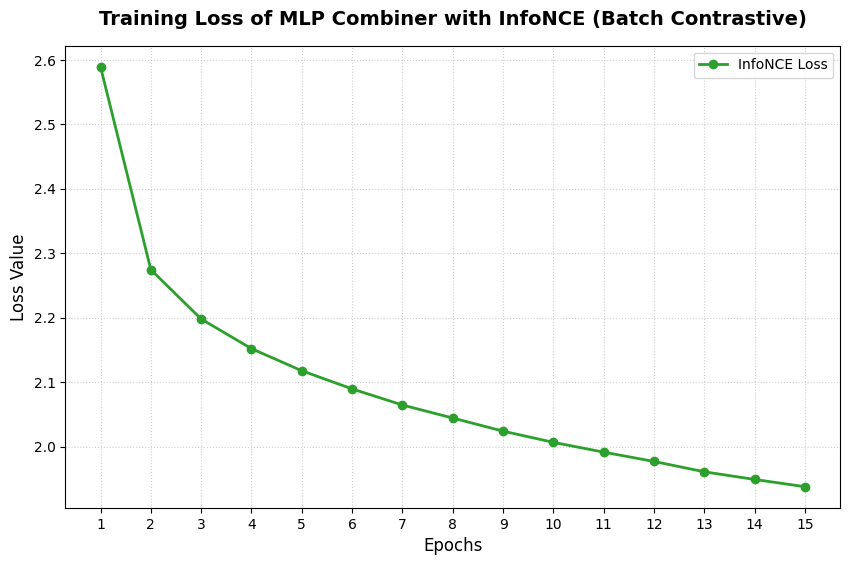

In [4]:
import os
import json
import time
import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from pathlib import Path
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

# ============================================================ #
# 1. CẤU HÌNH & THIẾT BỊ                                       #
# ============================================================ #
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"[INFO] Đang sử dụng thiết bị: {DEVICE}")

FIXED_OUTPUT_DIR = Path("/kaggle/working/fixed_test_data")
TRAIN_JSON_PATH = FIXED_OUTPUT_DIR / "fashion_train_combined_clean.json"

# Đường dẫn tới 2 file đặc trưng .pt đã lưu ở bước trước
LOAD_IMAGE_FEATURES_PATH = FIXED_OUTPUT_DIR / "image_features_precomputed.pt"
LOAD_TEXT_FEATURES_PATH = FIXED_OUTPUT_DIR / "text_features_precomputed.pt"

# ============================================================ #
# 2. KIẾN TRÚC MẠNG MLP COMBINER (BASELINE)                    #
# ============================================================ #
class MLPCombiner(nn.Module):
    def __init__(self, input_dim=512, hidden_dim=1024, output_dim=512):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(input_dim * 2, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.3),
            
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.BatchNorm1d(hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(0.2),
            
            nn.Linear(hidden_dim // 2, output_dim)
        )
        
    def forward(self, image_emb, text_emb):
        x = torch.cat([image_emb, text_emb], dim=-1)
        out = self.mlp(x)
        return F.normalize(out, dim=-1)


# ============================================================ #
# 3. ĐỊNH NGHĨA HÀM LOSS INFONCE & DATASET NÂNG CẤP            #
# ============================================================ #
class InfoNCELoss(nn.Module):
    """
    Hàm loss Contrastive dựa trên Batch (InfoNCE).
    Ép ma trận dự đoán phải trùng khớp với ma trận mục tiêu trên đường chéo chính,
    đồng thời đẩy xa tất cả các mẫu khác xuất hiện trong cùng một Batch.
    """
    def __init__(self, temperature=0.07):
        super().__init__()
        self.temperature = temperature
        
    def forward(self, predicted_target, pos_emb):
        # Đảm bảo các vector mục tiêu cũng đã được chuẩn hóa L2
        pos_emb = F.normalize(pos_emb, dim=-1)
        
        # Tính toán ma trận tương đồng giữa các mẫu trong Batch: [Batch_Size, Batch_Size]
        # Mỗi hàng i đại diện cho điểm tương đồng của truy vấn i với tất cả ảnh đích j trong batch
        logits = torch.matmul(predicted_target, pos_emb.T) / self.temperature
        
        # Nhãn đúng (Ground Truth) chính là vị trí đường chéo chính (i == j)
        batch_size = predicted_target.size(0)
        labels = torch.arange(batch_size, device=predicted_target.device)
        
        # Sử dụng Cross Entropy để tối ưu hóa đồng thời lực hút đường chéo và lực đẩy xung quanh
        loss = F.cross_entropy(logits, labels)
        return loss

class SavedFeatureContrastiveDataset(Dataset):
    """ Dataset rút gọn: Không cần bốc mẫu Negative ngẫu nhiên nữa """
    def __init__(self, image_features_dict, text_features_tensor, data_list):
        self.image_features = image_features_dict
        self.text_features = text_features_tensor
        self.data_list = data_list
        
    def __len__(self):
        return len(self.data_list)
        
    def __getitem__(self, idx):
        item = self.data_list[idx]
        cand_path = item["candidate"]
        targ_path = item["target"]
        
        cand_emb = self.image_features[cand_path]
        pos_emb = self.image_features[targ_path]
        text_emb = self.text_features[idx]
        
        return cand_emb, text_emb, pos_emb


# ============================================================ #
# 4. NẠP DỮ LIỆU ĐẶC TRƯNG ĐÃ TÍNH TOÁN TRƯỚC                  #
# ============================================================ #
print("[INFO] Đang nạp các file đặc trưng precomputed từ ổ đĩa...")
with open(TRAIN_JSON_PATH, "r", encoding="utf-8") as f:
    train_data = json.load(f)

image_features_dict = torch.load(LOAD_IMAGE_FEATURES_PATH, map_location="cpu")
text_features_tensor = torch.load(LOAD_TEXT_FEATURES_PATH, map_location="cpu")

print(f"[SUCCESS] Đã nạp {len(image_features_dict)} ảnh và {text_features_tensor.shape[0]} vector chữ vào RAM!")


# ============================================================ #
# 5. TIẾN HÀNH HUẤN LUYỆN MẠNG MLP VỚI INFONCE LOSS            #
# ============================================================ #
train_dataset = SavedFeatureContrastiveDataset(image_features_dict, text_features_tensor, train_data)

# CHÚ Ý: Bắt buộc phải đặt drop_last=True để kích thước ma trận vuông [512, 512] đồng nhất ở batch cuối
train_loader = DataLoader(train_dataset, batch_size=512, shuffle=True, drop_last=True)

mlp_model = MLPCombiner(input_dim=512, hidden_dim=1024, output_dim=512).to(DEVICE)
criterion = InfoNCELoss(temperature=0.07)
optimizer = torch.optim.AdamW(mlp_model.parameters(), lr=1e-3, weight_decay=1e-4)

epochs = 15
mlp_loss_history = []

print(f"\n[START] Bắt đầu huấn luyện mạng MLP Combiner với InfoNCE Loss trong {epochs} Epochs...")
for epoch in range(epochs):
    mlp_model.train()
    epoch_loss = 0.0
    
    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}")
    for cand_emb, text_emb, pos_emb in pbar:
        cand_emb = cand_emb.to(DEVICE)
        text_emb = text_emb.to(DEVICE)
        pos_emb = pos_emb.to(DEVICE)
        
        optimizer.zero_grad()
        
        # Lấy vector dự đoán của bộ trộn
        predicted_target = mlp_model(cand_emb, text_emb)
        
        # Tính toán InfoNCE Loss (1 mẫu đúng đấu chọi với 511 mẫu sai trong batch)
        loss = criterion(predicted_target, pos_emb)
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item()
        pbar.set_postfix({"loss": f"{loss.item():.4f}"})
        
    avg_loss = epoch_loss / len(train_loader)
    mlp_loss_history.append(avg_loss)
    print(f"-> Epoch {epoch+1}/{epochs} | InfoNCE Training Loss: {avg_loss:.4f}\n")

# Lưu trọng số của mạng MLP sau khi train với hàm Loss mới
mlp_save_path = FIXED_OUTPUT_DIR / "mlp_combiner_infonce.pt"
torch.save(mlp_model.state_dict(), mlp_save_path)
print(f"[DONE] Đã lưu mô hình tại: {mlp_save_path}")


# ============================================================ #
# 6. VẼ BIỂU ĐỒ LOSS ĐỂ ĐÁNH GIÁ MỨC ĐỘ HỘI TỤ                 #
# ============================================================ #
print("[INFO] Đang vẽ biểu đồ học tập của mạng MLP...")
plt.figure(figsize=(10, 6))
plt.plot(range(1, epochs + 1), mlp_loss_history, marker='o', linestyle='-', color='#2ca02c', linewidth=2, label='InfoNCE Loss')
plt.title('Training Loss of MLP Combiner with InfoNCE (Batch Contrastive)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss Value', fontsize=12)
plt.xticks(range(1, epochs + 1))
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()

plot_path = FIXED_OUTPUT_DIR / "mlp_infonce_loss_curve.png"
plt.savefig(plot_path, dpi=300, bbox_inches='tight')
print(f"[DONE] Biểu đồ hoàn tất! Đã lưu tại: {plot_path}")

plt.show()

# Đánh giá MLP của PhoBERT(Unfreeze)

In [8]:
import os
import json
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from pathlib import Path
import numpy as np
from tqdm.auto import tqdm
from PIL import Image
import py_vncorenlp
from transformers import AutoTokenizer, AutoModel, CLIPModel, CLIPProcessor
from transformers import logging as transformers_logging
import time

# Ẩn các thông báo đỏ/cảnh báo không cần thiết từ Hugging Face
transformers_logging.set_verbosity_error()

# ============================================================ #
# 1. CẤU HÌNH ĐƯỜNG DẪN & THIẾT BỊ                              #
# ============================================================ #
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"[INFO] Đang sử dụng thiết bị: {DEVICE}")

FASHION_ROOT = Path("/kaggle/input/datasets/mayukh18/fashion200k-dataset")
FIXED_OUTPUT_DIR = Path("/kaggle/working/fixed_test_data")
FIXED_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Đường dẫn file dữ liệu Test JSON đầu vào
TEST_JSON_PATH = FIXED_OUTPUT_DIR / "fashion_test_combined_clean.json"

# Đường dẫn lưu trữ/nạp trọng số mô hình
PHOBERT_STUDENT_PT = "/kaggle/input/datasets/npnam0123/phobert-false-01/student_best (2).pt"
MLP_CHECKPOINT_PATH = FIXED_OUTPUT_DIR / "mlp_combiner_infonce.pt"
FASHION_CLIP_NAME = "patrickjohncyh/fashion-clip"

# Khởi tạo bộ tách từ tiếng Việt VnCoreNLP
if 'rdrsegmenter' not in globals():
    if not os.path.exists('/kaggle/working/VnCoreNLP-1.2.jar'):
        py_vncorenlp.download_model(save_dir='/kaggle/working')
    rdrsegmenter = py_vncorenlp.VnCoreNLP(annotators=["wseg"], save_dir='/kaggle/working')


# ============================================================ #
# 2. KHAI BÁO KIẾN TRÚC MÔ HÌNH (Khớp với quá trình Train)     #
# ============================================================ #
class PhoBERTFashionCLIPStudent(nn.Module):
    def __init__(self, phobert_name="vinai/phobert-base-v2", out_dim=512):
        super().__init__()
        self.encoder = AutoModel.from_pretrained(phobert_name)
        hidden_size = self.encoder.config.hidden_size
        self.projection = nn.Sequential(
            nn.Linear(hidden_size, hidden_size),
            nn.GELU(),
            nn.LayerNorm(hidden_size),
            nn.Dropout(0.1),
            nn.Linear(hidden_size, out_dim),
        )
        
    def load_state_dict_flexible(self, checkpoint_path, device):
        checkpoint = torch.load(checkpoint_path, map_location=device)
        state_dict = checkpoint["model_state_dict"] if "model_state_dict" in checkpoint else checkpoint
        new_state_dict = {k.replace("roberta.", "encoder.", 1) if k.startswith("roberta.") else k: v for k, v in state_dict.items()}
        self.load_state_dict(new_state_dict, strict=False)
        print(f"[LOAD SUCCESS] Đã nạp thành công PhoBERT Student!")

    def forward(self, input_ids, attention_mask):
        outputs = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        cls = outputs.last_hidden_state[:, 0, :]
        emb = self.projection(cls)
        return F.normalize(emb, dim=-1)


class MLPCombiner(nn.Module):
    def __init__(self, input_dim=512, hidden_dim=1024, output_dim=512):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(input_dim * 2, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.3),
            
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.BatchNorm1d(hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(0.2),
            
            nn.Linear(hidden_dim // 2, output_dim)
        )
        
    def forward(self, image_emb, text_emb):
        x = torch.cat([image_emb, text_emb], dim=-1)
        out = self.mlp(x)
        return F.normalize(out, dim=-1)


# ============================================================ #
# 3. NẠP MÔ HÌNH VÀ DỮ LIỆU                                   #
# ============================================================ #
print("\n[INFO] Đang khởi tạo các mô hình Encoders & MLP Combiner...")
tokenizer = AutoTokenizer.from_pretrained("vinai/phobert-base-v2")

text_encoder = PhoBERTFashionCLIPStudent().to(DEVICE)
text_encoder.load_state_dict_flexible(PHOBERT_STUDENT_PT, DEVICE)
text_encoder.eval()

clip_model = CLIPModel.from_pretrained(FASHION_CLIP_NAME).to(DEVICE)
clip_processor = CLIPProcessor.from_pretrained(FASHION_CLIP_NAME)
clip_model.eval()

mlp_model = MLPCombiner(input_dim=512, hidden_dim=1024, output_dim=512).to(DEVICE)
mlp_model.load_state_dict(torch.load(MLP_CHECKPOINT_PATH, map_location=DEVICE))
mlp_model.eval()

with open(TEST_JSON_PATH, "r", encoding="utf-8") as f:
    test_data = json.load(f)
print(f"[INFO] Tổng số lượng mẫu Test tìm thấy: {len(test_data)}")


# ============================================================ #
# 4. TRÍCH XUẤT TRỰC TIẾP ĐẶC TRƯNG TẬP TEST TRÊN RAM          #
# ============================================================ #
# --- A. Trích xuất đặc trưng Ảnh Tập Test ---
unique_test_images = set()
for item in test_data:
    unique_test_images.add(item["candidate"])
    unique_test_images.add(item["target"])
unique_test_images = list(unique_test_images)

image_features_dict = {}
print("\n[INFO] Đang trích xuất đặc trưng Ảnh tập Test qua FashionCLIP...")

start_img_time = time.time()
with torch.no_grad():
    for i in tqdm(range(0, len(unique_test_images), 128), desc="Extracting Test Images"):
        batch_paths = unique_test_images[i:i+128]
        images = []
        valid_paths = []
        
        for p in batch_paths:
            full_p = FASHION_ROOT / p
            if full_p.exists():
                try:
                    images.append(Image.open(full_p).convert("RGB"))
                    valid_paths.append(p)
                except Exception:
                    continue
                
        if not images: 
            continue
            
        inputs = clip_processor(images=images, return_tensors="pt").to(DEVICE)
        img_outputs = clip_model.get_image_features(**inputs)
        
        if hasattr(img_outputs, "pooler_output") and img_outputs.pooler_output is not None:
            img_embs = img_outputs.pooler_output
        elif hasattr(img_outputs, "last_hidden_state"):
            img_embs = img_outputs.last_hidden_state[:, 0, :]
        else:
            img_embs = img_outputs
            
        img_embs = F.normalize(img_embs, dim=-1).cpu()
        
        for p, emb in zip(valid_paths, img_embs):
            image_features_dict[p] = emb
end_img_time = time.time()

# --- B. Trích xuất đặc trưng Văn bản Tập Test ---
text_features_list = []
print("\n[INFO] Đang trích xuất đặc trưng Văn bản tiếng Việt tập Test qua PhoBERT Student...")

start_txt_time = time.time()
with torch.no_grad():
    for i in tqdm(range(0, len(test_data), 128), desc="Extracting Test Texts"):
        batch_items = test_data[i:i+128]
        captions_segmented = []
        
        for item in batch_items:
            raw_vi = item.get("captions_vi", item.get("text_vi", [""]))[0]
            seg_vi = rdrsegmenter.word_segment(raw_vi)[0]
            captions_segmented.append(seg_vi)
            
        inputs = tokenizer(captions_segmented, padding=True, truncation=True, max_length=128, return_tensors="pt").to(DEVICE)
        txt_embs = text_encoder(inputs["input_ids"], inputs["attention_mask"]).cpu()
        
        for emb in txt_embs:
            text_features_list.append(emb)

text_features_tensor = torch.stack(text_features_list)
end_txt_time = time.time()

# Giải phóng bộ nhớ của Encoders cồng kềnh để tránh tràn VRAM
del clip_model, text_encoder
torch.cuda.empty_cache()


# ============================================================ #
# 5. KHỞI TẠO KHO ẢNH GALLERY TÌM KIẾM (TARGET GALLERY)        #
# ============================================================ #
gallery_paths = list(set([item["target"] for item in test_data if item["target"] in image_features_dict]))
gallery_tensor = torch.stack([image_features_dict[p] for p in gallery_paths]).to(DEVICE)

print(f"\n[INFO] Khởi tạo kho ảnh Gallery gồm: {len(gallery_paths)} ảnh.")


# ============================================================ #
# 6. TIẾN HÀNH ĐÁNH GIÁ (INFERENCE & METRICS - OPTIMIZED)      #
# ============================================================ #
def calculate_recall(ranks, k):
    return 100.0 * np.sum(ranks < k) / len(ranks)

gallery_path_to_idx = {path: idx for idx, path in enumerate(gallery_paths)}
ranks_list = []

valid_test_indices = []
for idx, item in enumerate(test_data):
    if item["candidate"] in image_features_dict and item["target"] in image_features_dict:
        valid_test_indices.append(idx)

print(f"\n[INFO] Số lượng mẫu kiểm thử hợp lệ sau bộ lọc: {len(valid_test_indices)}/{len(test_data)}")
print("[INFO] Đang tiến hành tính toán song song ma trận tương đồng trên GPU theo Batch...")

EVAL_BATCH_SIZE = 256
mlp_model.eval()

start_search_time = time.time()
with torch.no_grad():
    for i in tqdm(range(0, len(valid_test_indices), EVAL_BATCH_SIZE), desc="Evaluating MLP"):
        batch_idxs = valid_test_indices[i : i + EVAL_BATCH_SIZE]
        
        batch_cand_embs = torch.stack([image_features_dict[test_data[idx]["candidate"]] for idx in batch_idxs]).to(DEVICE)
        batch_text_embs = text_features_tensor[batch_idxs].to(DEVICE)
        
        predicted_target_embs = mlp_model(batch_cand_embs, batch_text_embs)
        similarities = torch.matmul(predicted_target_embs, gallery_tensor.T)
        
        sorted_indices = torch.argsort(similarities, descending=True, dim=-1).cpu().numpy()
        
        for j, idx in enumerate(batch_idxs):
            targ_path = test_data[idx]["target"]
            correct_target_idx = gallery_path_to_idx[targ_path]
            
            rank = np.where(sorted_indices[j] == correct_target_idx)[0][0]
            ranks_list.append(rank)
end_search_time = time.time()

# --- TÍNH TOÁN CÁC METRICS THỜI GIAN ---
total_img_time = end_img_time - start_img_time
total_txt_time = end_txt_time - start_txt_time
total_search_time = end_search_time - start_search_time

avg_img_time_per_sample = total_img_time / len(unique_test_images)
avg_txt_time_per_sample = total_txt_time / len(test_data)
avg_search_time_per_sample = total_search_time / len(valid_test_indices)

# Tổng thời gian pipeline chạy theo Batch
total_pipeline_avg_time = avg_img_time_per_sample + avg_txt_time_per_sample + avg_search_time_per_sample

ranks_array = np.array(ranks_list)
r1 = calculate_recall(ranks_array, 1)
r5 = calculate_recall(ranks_array, 5)
r10 = calculate_recall(ranks_array, 10)
r50 = calculate_recall(ranks_array, 50)
mean_rank = np.mean(ranks_array) + 1


# ============================================================ #
# 7. HIỂN THỊ KẾT QUẢ ĐÁNH GIÁ                                 #
# ============================================================ #
print("\n" + "="*60)
print(f"📊 KẾT QUẢ ĐÁNH GIÁ HỆ THỐNG TRÊN TẬP TEST 📊")
print("="*60)
print(f"• Tổng số mẫu test hợp lệ        : {len(ranks_list)}")
print(f"• Kích thước tập Gallery         : {len(gallery_paths)} ảnh")
print(f"• Recall@1                       : {r1:.2f}%")
print(f"• Recall@5                       : {r5:.2f}%")
print(f"• Recall@10                      : {r10:.2f}%")
print(f"• Recall@50                      : {r50:.2f}%")
print(f"• Mean Rank (Thứ hạng trung bình): {mean_rank:.2f}")
print("-" * 60)
print("⏱️  PHÂN TÍCH THỜI GIAN CHẠY TRUNG BÌNH (BATCH MODE)  ⏱️")
print(f"• [1] Trích xuất ảnh (CLIP)      : {avg_img_time_per_sample * 1000:.2f} ms/mẫu")
print(f"• [2] Trích xuất chữ (PhoBERT)   : {avg_txt_time_per_sample * 1000:.2f} ms/mẫu")
print(f"• [3] Tìm kiếm (MLP + Ma trận)   : {avg_search_time_per_sample * 1000:.2f} ms/mẫu")
print(f"👉 Tổng thời gian xử lý (1+2+3)   : {total_pipeline_avg_time * 1000:.2f} ms/mẫu")
print("="*60)

[INFO] Đang sử dụng thiết bị: cuda

[INFO] Đang khởi tạo các mô hình Encoders & MLP Combiner...


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[LOAD SUCCESS] Đã nạp thành công PhoBERT Student!


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

[INFO] Tổng số lượng mẫu Test tìm thấy: 5000

[INFO] Đang trích xuất đặc trưng Ảnh tập Test qua FashionCLIP...


...


[INFO] Đang trích xuất đặc trưng Văn bản tiếng Việt tập Test qua PhoBERT Student...


Extracting Test Texts:   0%|          | 0/40 [00:00<?, ?it/s]


[INFO] Khởi tạo kho ảnh Gallery gồm: 4545 ảnh.

[INFO] Số lượng mẫu kiểm thử hợp lệ sau bộ lọc: 5000/5000
[INFO] Đang tiến hành tính toán song song ma trận tương đồng trên GPU theo Batch...


Evaluating MLP:   0%|          | 0/20 [00:00<?, ?it/s]


📊 KẾT QUẢ ĐÁNH GIÁ HỆ THỐNG TRÊN TẬP TEST 📊
• Tổng số mẫu test hợp lệ        : 5000
• Kích thước tập Gallery         : 4545 ảnh
• Recall@1                       : 26.10%
• Recall@5                       : 54.26%
• Recall@10                      : 66.44%
• Recall@50                      : 90.10%
• Mean Rank (Thứ hạng trung bình): 22.77
------------------------------------------------------------
⏱️  PHÂN TÍCH THỜI GIAN CHẠY TRUNG BÌNH (BATCH MODE)  ⏱️
• [1] Trích xuất ảnh (CLIP)      : 9.27 ms/mẫu
• [2] Trích xuất chữ (PhoBERT)   : 3.46 ms/mẫu
• [3] Tìm kiếm (MLP + Ma trận)   : 0.03 ms/mẫu
👉 Tổng thời gian xử lý (1+2+3)   : 12.76 ms/mẫu


# Huấn luyện ConCat+Linear PhoBERT(Unfreeze)

[INFO] Đang sử dụng thiết bị huấn luyện Concat+Linear: cuda
[INFO] Đang nạp dữ liệu...

[START] Bắt đầu huấn luyện Concat+Linear Combiner trong 15 Epochs...


Epoch 1/15:   0%|          | 0/351 [00:00<?, ?it/s]

-> Epoch 01/15 | Loss: 2.4131 | Thời gian: 2.8s


Epoch 2/15:   0%|          | 0/351 [00:00<?, ?it/s]

-> Epoch 02/15 | Loss: 2.2805 | Thời gian: 2.8s


...

-> Epoch 13/15 | Loss: 2.2144 | Thời gian: 2.9s


Epoch 14/15:   0%|          | 0/351 [00:00<?, ?it/s]

-> Epoch 14/15 | Loss: 2.2121 | Thời gian: 2.9s


Epoch 15/15:   0%|          | 0/351 [00:00<?, ?it/s]

-> Epoch 15/15 | Loss: 2.2112 | Thời gian: 2.8s

[DONE] Đã lưu mô hình Concat+Linear tại: /kaggle/working/fixed_test_data/concat_linear_pure_infonce_best.pt


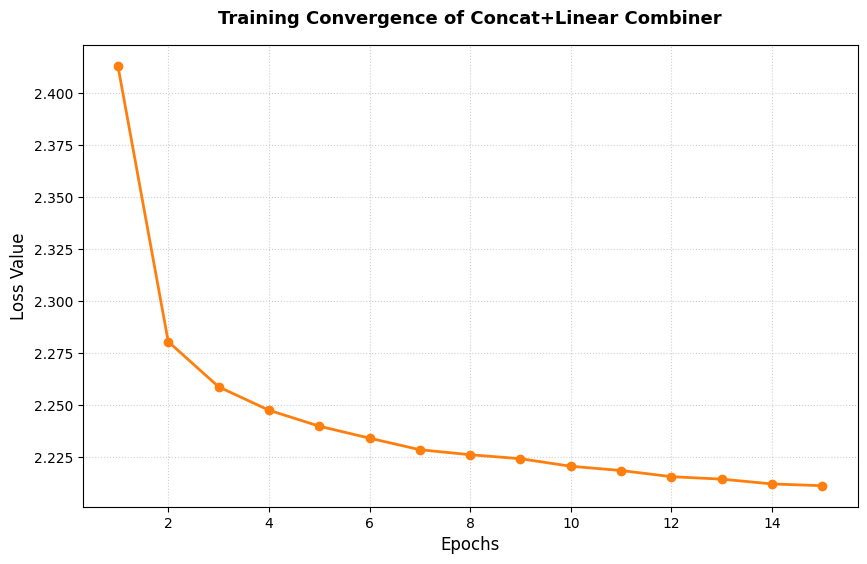

In [40]:
import os
import json
import time
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from pathlib import Path
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

# ============================================================ #
# 1. CẤU HÌNH ĐƯỜNG DẪN & THIẾT BỊ                            #
# ============================================================ #
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"[INFO] Đang sử dụng thiết bị huấn luyện Concat+Linear: {DEVICE}")

FIXED_OUTPUT_DIR = Path("/kaggle/working/fixed_test_data")
FIXED_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
TRAIN_JSON_PATH = FIXED_OUTPUT_DIR / "fashion_train_combined_clean.json"

LOAD_IMAGE_FEATURES_PATH = FIXED_OUTPUT_DIR / "image_features_precomputed.pt"
LOAD_TEXT_FEATURES_PATH = FIXED_OUTPUT_DIR / "text_features_precomputed.pt"


# ============================================================ #
# 2. KIẾN TRÚC MẠNG CONCAT + LINEAR (SIÊU TỐI GIẢN)           #
# ============================================================ #
class ConcatLinearCombiner(nn.Module):
    """
    Bộ trộn tối giản nhất có thể: 
    Nối [Ảnh, Chữ] -> Nhân ma trận Linear -> Cộng ảnh gốc -> Chuẩn hóa.
    Không dùng lớp ẩn (hidden layers), không dùng hàm kích hoạt phi tuyến.
    """
    def __init__(self, dim=512):
        super().__init__()
        # Nén trực tiếp từ 1024 (512 Ảnh + 512 Chữ) về 512 chiều
        self.proj = nn.Linear(dim * 2, dim)
        self.layer_norm = nn.LayerNorm(dim)

    def forward(self, image_emb, text_emb):
        # 1. Nối chuỗi (Concatenate)
        merged = torch.cat([image_emb, text_emb], dim=-1)
        
        # 2. Ánh xạ tuyến tính (Linear Projection)
        out = self.proj(merged)
        
        # 3. Mạch thặng dư (Residual) để giữ bản sắc ảnh gốc
        out = self.layer_norm(out + image_emb) 
        
        return F.normalize(out, dim=-1)


# ============================================================ #
# 3. ĐỊNH NGHĨA HÀM LOSS INFONCE & DATASET                     #
# ============================================================ #
class InfoNCELoss(nn.Module):
    def __init__(self, temperature=0.07):
        super().__init__()
        self.temperature = temperature
        
    def forward(self, predicted_target, pos_emb):
        pos_emb = F.normalize(pos_emb, dim=-1)
        logits = torch.matmul(predicted_target, pos_emb.T) / self.temperature
        batch_size = predicted_target.size(0)
        labels = torch.arange(batch_size, device=predicted_target.device)
        return F.cross_entropy(logits, labels)

class SavedFeatureContrastiveDataset(Dataset):
    def __init__(self, image_features_dict, text_features_tensor, data_list):
        self.image_features = image_features_dict
        self.text_features = text_features_tensor
        self.data_list = data_list
        
    def __len__(self):
        return len(self.data_list)
        
    def __getitem__(self, idx):
        item = self.data_list[idx]
        return self.image_features[item["candidate"]], self.text_features[idx], self.image_features[item["target"]]


# ============================================================ #
# 4. NẠP DỮ LIỆU ĐẶC TRƯNG VÀO RAM                            #
# ============================================================ #
print("[INFO] Đang nạp dữ liệu...")
with open(TRAIN_JSON_PATH, "r", encoding="utf-8") as f:
    train_data = json.load(f)

image_features_dict = torch.load(LOAD_IMAGE_FEATURES_PATH, map_location="cpu")
text_features_tensor = torch.load(LOAD_TEXT_FEATURES_PATH, map_location="cpu")


# ============================================================ #
# 5. TIẾN HÀNH HUẤN LUYỆN MẠNG LINEAR                          #
# ============================================================ #
train_dataset = SavedFeatureContrastiveDataset(image_features_dict, text_features_tensor, train_data)
train_loader = DataLoader(train_dataset, batch_size=512, shuffle=True, drop_last=True)

# Khởi tạo mô hình
combiner = ConcatLinearCombiner(dim=512).to(DEVICE)
criterion = InfoNCELoss(temperature=0.07)
# Tăng weight_decay một chút để ma trận Linear mượt mà
optimizer = torch.optim.AdamW(combiner.parameters(), lr=1e-3, weight_decay=1e-2)

epochs = 15 # Cực kỳ đơn giản nên 30 epochs là đủ hội tụ
loss_history = []

print(f"\n[START] Bắt đầu huấn luyện Concat+Linear Combiner trong {epochs} Epochs...")

for epoch in range(epochs):
    combiner.train()
    epoch_loss = 0.0
    start_time = time.time()
    
    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}")
    for cand_emb, text_emb, pos_emb in pbar:
        cand_emb, text_emb, pos_emb = cand_emb.to(DEVICE), text_emb.to(DEVICE), pos_emb.to(DEVICE)
        
        optimizer.zero_grad()
        predicted_target = combiner(cand_emb, text_emb)
        loss = criterion(predicted_target, pos_emb)
        
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item()
        pbar.set_postfix({"Loss": f"{loss.item():.4f}"})
        
    avg_loss = epoch_loss / len(train_loader)
    loss_history.append(avg_loss)
    elapsed_time = time.time() - start_time
    print(f"-> Epoch {epoch+1:02d}/{epochs:02d} | Loss: {avg_loss:.4f} | Thời gian: {elapsed_time:.1f}s")

# Lưu checkpoint
combiner_save_path = FIXED_OUTPUT_DIR / "concat_linear_pure_infonce_best.pt"
torch.save(combiner.state_dict(), combiner_save_path)
print(f"\n[DONE] Đã lưu mô hình Concat+Linear tại: {combiner_save_path}")

# Vẽ đồ thị
plt.figure(figsize=(10, 6))
plt.plot(range(1, epochs + 1), loss_history, marker='o', linestyle='-', color='#ff7f0e', linewidth=2)
plt.title('Training Convergence of Concat+Linear Combiner', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss Value', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)
plt.savefig(FIXED_OUTPUT_DIR / "concat_linear_loss_curve.png", dpi=300)
plt.show()

# Huấn luyện ConCat+Linear PhoBERT(Unfreeze)

In [49]:
import os
import json
import numpy as np  
import torch
import torch.nn as nn
import torch.nn.functional as F
from pathlib import Path
from tqdm.auto import tqdm
from PIL import Image
import py_vncorenlp
from transformers import AutoTokenizer, AutoModel, CLIPModel, CLIPProcessor
from transformers import logging as transformers_logging

transformers_logging.set_verbosity_error()

# ============================================================ #
# 1. CẤU HÌNH ĐƯỜNG DẪN & THIẾT BỊ                            #
# ============================================================ #
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"[INFO] Đang sử dụng thiết bị để đánh giá: {DEVICE}")

FASHION_ROOT = Path("/kaggle/input/datasets/mayukh18/fashion200k-dataset")
FIXED_OUTPUT_DIR = Path("/kaggle/working/fixed_test_data")

TEST_JSON_PATH = FIXED_OUTPUT_DIR / "fashion_test_combined_clean.json" 
PHOBERT_STUDENT_PT = "/kaggle/input/datasets/npnam0123/phobert-false-01/student_best (2).pt"
COMBINER_PT = FIXED_OUTPUT_DIR / "concat_linear_pure_infonce_best.pt"  # Trỏ đúng file mới
FASHION_CLIP_NAME = "patrickjohncyh/fashion-clip"

if 'rdrsegmenter' not in globals():
    rdrsegmenter = py_vncorenlp.VnCoreNLP(annotators=["wseg"], save_dir='/kaggle/working')

# ============================================================ #
# 2. KHAI BÁO KIẾN TRÚC MÔ HÌNH ĐỒNG BỘ                       #
# ============================================================ #
class PhoBERTFashionCLIPStudent(nn.Module):
    def __init__(self, phobert_name="vinai/phobert-base-v2", out_dim=512):
        super().__init__()
        self.encoder = AutoModel.from_pretrained(phobert_name)
        hidden_size = self.encoder.config.hidden_size
        self.projection = nn.Sequential(
            nn.Linear(hidden_size, hidden_size), nn.GELU(),
            nn.LayerNorm(hidden_size), nn.Dropout(0.1), nn.Linear(hidden_size, out_dim),
        )
    def load_state_dict_flexible(self, checkpoint_path, device):
        checkpoint = torch.load(checkpoint_path, map_location=device)
        state_dict = checkpoint["model_state_dict"] if "model_state_dict" in checkpoint else checkpoint
        new_state_dict = {k.replace("roberta.", "encoder.", 1) if k.startswith("roberta.") else k: v for k, v in state_dict.items()}
        self.load_state_dict(new_state_dict, strict=False)
    def forward(self, input_ids, attention_mask):
        outputs = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        return F.normalize(self.projection(outputs.last_hidden_state[:, 0, :]), dim=-1)

class ConcatLinearCombiner(nn.Module):
    """ Mạng đồng bộ với lúc train """
    def __init__(self, dim=512):
        super().__init__()
        self.proj = nn.Linear(dim * 2, dim)
        self.layer_norm = nn.LayerNorm(dim)

    def forward(self, image_emb, text_emb):
        merged = torch.cat([image_emb, text_emb], dim=-1)
        out = self.proj(merged)
        out = self.layer_norm(out + image_emb) 
        return F.normalize(out, dim=-1)

# ============================================================ #
# 3. NẠP MÔ HÌNH VÀ DỮ LIỆU KIỂM THỬ                          #
# ============================================================ #
print("\n[INFO] Đang nạp mô hình Concat+Linear để đánh giá...")
tokenizer = AutoTokenizer.from_pretrained("vinai/phobert-base-v2")

text_encoder = PhoBERTFashionCLIPStudent().to(DEVICE)
text_encoder.load_state_dict_flexible(PHOBERT_STUDENT_PT, DEVICE)
text_encoder.eval()

clip_model = CLIPModel.from_pretrained(FASHION_CLIP_NAME).to(DEVICE)
clip_processor = CLIPProcessor.from_pretrained(FASHION_CLIP_NAME)
clip_model.eval()

combiner = ConcatLinearCombiner(dim=512).to(DEVICE)
combiner.load_state_dict(torch.load(COMBINER_PT, map_location=DEVICE))
combiner.eval()

with open(TEST_JSON_PATH, "r", encoding="utf-8") as f:
    test_data = json.load(f)

# ============================================================ #
# 4. TRÍCH XUẤT ĐẶC TRƯNG TẬP GALLERY                         #
# ============================================================ #
target_images = list(set([item["target"] for item in test_data]))
target_image_features = {}

print("\n[INFO] Đang trích xuất đặc trưng Gallery...")
with torch.no_grad():
    for i in tqdm(range(0, len(target_images), 128)):
        batch_paths = target_images[i:i+128]
        images = [Image.open(FASHION_ROOT / p).convert("RGB") for p in batch_paths if (FASHION_ROOT / p).exists()]
        valid_paths = [p for p in batch_paths if (FASHION_ROOT / p).exists()]
        if not images: continue
        
        inputs = clip_processor(images=images, return_tensors="pt").to(DEVICE)
        img_outputs = clip_model.get_image_features(**inputs)
        
        if hasattr(img_outputs, "pooler_output") and img_outputs.pooler_output is not None:
            img_embs = img_outputs.pooler_output
        elif hasattr(img_outputs, "last_hidden_state"):
            img_embs = img_outputs.last_hidden_state[:, 0, :]
        else:
            img_embs = img_outputs
            
        img_embs = F.normalize(img_embs, dim=-1).cpu()
        for p, emb in zip(valid_paths, img_embs): 
            target_image_features[p] = emb

gallery_paths = list(target_image_features.keys())
gallery_tensor = torch.stack([target_image_features[p] for p in gallery_paths]).to(DEVICE) 

# ============================================================ #
# 5. TÍNH TOÁN METRICS RECALL@K                               #
# ============================================================ #
print("\n[INFO] Đang tính toán Metrics (Recall@K)...")
def calculate_recall(ranks, k):
    return 100.0 * np.sum(ranks < k) / len(ranks)

ranks_list = []
with torch.no_grad():
    for item in tqdm(test_data):
        cand_path, targ_path = item["candidate"], item["target"]
        if targ_path not in target_image_features or not (FASHION_ROOT / cand_path).exists(): continue
        
        cand_img = Image.open(FASHION_ROOT / cand_path).convert("RGB")
        cand_inputs = clip_processor(images=[cand_img], return_tensors="pt").to(DEVICE)
        c_out = clip_model.get_image_features(**cand_inputs)
        
        if hasattr(c_out, "pooler_output") and c_out.pooler_output is not None:
            c_emb = c_out.pooler_output
        elif hasattr(c_out, "last_hidden_state"):
            c_emb = c_out.last_hidden_state[:, 0, :]
        else:
            c_emb = c_out
        cand_emb = F.normalize(c_emb, dim=-1)
        
        raw_vi = item.get("captions_vi", item.get("text_vi", [""]))[0]
        seg_vi = rdrsegmenter.word_segment(raw_vi)[0]
        txt_inputs = tokenizer(seg_vi, padding=True, truncation=True, max_length=128, return_tensors="pt").to(DEVICE)
        text_emb = text_encoder(txt_inputs["input_ids"], txt_inputs["always_mask" if "always_mask" in txt_inputs else "attention_mask"])
        
        predicted_emb = combiner(cand_emb, text_emb) 
        
        similarities = torch.matmul(predicted_emb, gallery_tensor.T).squeeze(0) 
        sorted_indices = torch.argsort(similarities, descending=True).cpu().numpy()
        
        target_idx = gallery_paths.index(targ_path)
        rank = np.where(sorted_indices == target_idx)[0][0]
        ranks_list.append(rank)

ranks_array = np.array(ranks_list)
r1 = calculate_recall(ranks_array, 1)
r5 = calculate_recall(ranks_array, 5)
r10 = calculate_recall(ranks_array, 10)
r50 = calculate_recall(ranks_array, 50)
mean_rank = np.mean(ranks_array) + 1 

print("\n" + "="*50)
print(f"🚀 KẾT QUẢ ĐÁNH GIÁ (CONCAT + LINEAR) 🚀")
print("="*50)
print(f"Tổng số truy vấn hợp lệ : {len(ranks_list)}")
print(f"Kích thước tập Gallery  : {len(gallery_paths)} ảnh đích")
print(f"Recall@1                : {r1:.2f}%")
print(f"Recall@5                : {r5:.2f}%")
print(f"Recall@10               : {r10:.2f}%")
print(f"Recall@50               : {r50:.2f}%")
print(f"Mean Rank (Thứ hạng TB) : {mean_rank:.2f}")
print("="*50)

[INFO] Đang sử dụng thiết bị để đánh giá: cuda

[INFO] Đang nạp mô hình Concat+Linear để đánh giá...


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]


[INFO] Đang trích xuất đặc trưng Gallery...


  0%|          | 0/36 [00:00<?, ?it/s]


[INFO] Đang tính toán Metrics (Recall@K)...


  0%|          | 0/5000 [00:00<?, ?it/s]


🚀 KẾT QUẢ ĐÁNH GIÁ (CONCAT + LINEAR) 🚀
Tổng số truy vấn hợp lệ : 5000
Kích thước tập Gallery  : 4545 ảnh đích
Recall@1                : 22.60%
Recall@5                  : 51.18%
Recall@10               : 63.84%
Recall@50               : 88.34%
Mean Rank (Thứ hạng TB) : 26.48


# Danh Gia Combier(+) PhoBERT(UnFreeze)

In [5]:
import os
import json
import torch
import torch.nn as nn
import torch.nn.functional as F
from PIL import Image
from tqdm.auto import tqdm
from pathlib import Path
import py_vncorenlp
from transformers import AutoTokenizer, AutoModel, CLIPModel, CLIPProcessor

# ============================================================
# 1. CẤU HÌNH ĐƯỜNG DẪN & THIẾT BỊ
# ============================================================
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"[INFO] Đang sử dụng thiết bị: {DEVICE}")

FASHION_ROOT = Path("/kaggle/input/datasets/mayukh18/fashion200k-dataset")
TEST_JSON_PATH = Path("/kaggle/working/fixed_test_data/fashion_test_combined_clean.json")
PHOBERT_CHECKPOINT = "/kaggle/input/datasets/npnam0123/phobert-false-01/student_best (2).pt"
FASHION_CLIP_NAME = "patrickjohncyh/fashion-clip" # Hoặc tên model CLIP bạn dùng để lấy precomputed

# ============================================================
# 2. KHỞI TẠO MÔ HÌNH VÀ CÔNG CỤ (TEXT & IMAGE)
# ============================================================

# --- A. Khởi tạo VnCoreNLP ---
print("[INFO] Đang tải VnCoreNLP...")
if not os.path.exists('/kaggle/working/VnCoreNLP-1.2.jar'):
    py_vncorenlp.download_model(save_dir='/kaggle/working')

# Mẹo để tránh lỗi "VM is already running" khi chạy lại cell nhiều lần trên Kaggle/Colab
if 'rdrsegmenter' not in globals():
    try:
        rdrsegmenter = py_vncorenlp.VnCoreNLP(annotators=["wseg"], save_dir='/kaggle/working')
        print("[INFO] Đã khởi tạo thành công VnCoreNLP mới.")
    except ValueError as e:
        print("[WARNING] Máy ảo Java đã chạy. Vui lòng Restart Session (Kernel) trên Kaggle!")
else:
    print("[INFO] VnCoreNLP đã được khởi tạo từ trước, dùng luôn bản cũ trong RAM.")

# --- B. Định nghĩa & Nạp PhoBERT Student (Text Encoder) ---
class PhoBERTFashionCLIPStudent(nn.Module):
    def __init__(self, phobert_name="vinai/phobert-base-v2", out_dim=512):
        super().__init__()
        self.encoder = AutoModel.from_pretrained(phobert_name)
        hidden_size = self.encoder.config.hidden_size
        self.projection = nn.Sequential(
            nn.Linear(hidden_size, hidden_size),
            nn.GELU(),
            nn.LayerNorm(hidden_size),
            nn.Dropout(0.1),
            nn.Linear(hidden_size, out_dim),
        )

    def forward(self, input_ids, attention_mask):
        outputs = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        cls = outputs.last_hidden_state[:, 0, :]
        emb = self.projection(cls)
        return F.normalize(emb, dim=-1)

print("[INFO] Đang nạp Text Encoder (PhoBERT)...")
checkpoint = torch.load(PHOBERT_CHECKPOINT, map_location=DEVICE)
text_encoder = PhoBERTFashionCLIPStudent(
    phobert_name=checkpoint["config"]["phobert_name"],
    out_dim=checkpoint["embedding_dim"]
)
text_encoder.load_state_dict(checkpoint["model_state_dict"])
text_encoder.to(DEVICE)
text_encoder.eval()

tokenizer = AutoTokenizer.from_pretrained(checkpoint["config"]["phobert_name"])
MAX_LENGTH = checkpoint["max_length"]

# --- C. Nạp Image Encoder (FashionCLIP) ---
print("[INFO] Đang nạp Image Encoder (FashionCLIP)...")
image_encoder = CLIPModel.from_pretrained(FASHION_CLIP_NAME).vision_model
image_projection = CLIPModel.from_pretrained(FASHION_CLIP_NAME).visual_projection
image_processor = CLIPProcessor.from_pretrained(FASHION_CLIP_NAME)

image_encoder.to(DEVICE)
image_projection.to(DEVICE)
image_encoder.eval()
image_projection.eval()

# ============================================================
# 3. HÀM TRÍCH XUẤT ĐẶC TRƯNG (ĐÃ FIX LỖI FLOAT16)
# ============================================================
@torch.no_grad()
def get_text_embedding(text):
    # Tiền xử lý tiếng Việt
    segmented = " ".join(rdrsegmenter.word_segment(text))
    enc = tokenizer(segmented, padding="max_length", truncation=True, max_length=MAX_LENGTH, return_tensors="pt")
    input_ids = enc["input_ids"].to(DEVICE)
    attention_mask = enc["attention_mask"].to(DEVICE)
    
    # Cập nhật cú pháp autocast mới cho Pytorch
    with torch.autocast(device_type="cuda" if DEVICE == "cuda" else "cpu", enabled=(DEVICE == "cuda")):
        emb = text_encoder(input_ids, attention_mask)
        
    # Ép kiểu về float32 (.float()) để đồng bộ tính toán
    return emb.float()

@torch.no_grad()
def get_image_embedding(image_path):
    img = Image.open(image_path).convert("RGB")
    inputs = image_processor(images=img, return_tensors="pt").to(DEVICE)
    
    # Cập nhật cú pháp autocast mới cho Pytorch
    with torch.autocast(device_type="cuda" if DEVICE == "cuda" else "cpu", enabled=(DEVICE == "cuda")):
        vision_outputs = image_encoder(**inputs)
        image_embeds = vision_outputs[1] # Pooled output
        image_embeds = image_projection(image_embeds)
        
    # Ép kiểu về float32 (.float()) để đồng bộ tính toán
    return F.normalize(image_embeds, dim=-1).float()

# ============================================================
# 4. CHUẨN BỊ DỮ LIỆU ĐÁNH GIÁ (GALLERY & QUERIES)
# ============================================================
print("[INFO] Đang đọc file Test Data...")
with open(TEST_JSON_PATH, "r", encoding="utf-8") as f:
    test_data = json.load(f)

# Lấy danh sách tất cả các ảnh Target duy nhất để làm Gallery (Không gian tìm kiếm)
gallery_paths = list(set([item["target"] for item in test_data]))
print(f"[INFO] Tổng số ảnh trong Gallery: {len(gallery_paths)}")

print("[INFO] Đang trích xuất vector cho Gallery...")
gallery_embeddings = []
for path in tqdm(gallery_paths, desc="Gallery Features"):
    abs_path = FASHION_ROOT / path
    feat = get_image_embedding(abs_path)
    gallery_embeddings.append(feat.cpu())
    
gallery_embeddings = torch.cat(gallery_embeddings, dim=0) # [Num_Gallery, 512]

# ============================================================
# 5. TIẾN HÀNH TRUY VẤN VÀ ĐÁNH GIÁ RECALL@K
# ============================================================
print(f"[INFO] Bắt đầu đánh giá trên {len(test_data)} mẫu queries...")

k_vals = [1, 5, 10, 50]
hits = {k: 0 for k in k_vals}

for idx, item in enumerate(tqdm(test_data, desc="Evaluating CIR")):
    cand_path = FASHION_ROOT / item["candidate"]
    target_path = item["target"]
    
    # Lấy text tiếng Việt (Xử lý tùy dạng list hay string)
    raw_vi = item.get("captions_vi", item.get("caption_vi", ""))
    if isinstance(raw_vi, list): raw_vi = raw_vi[0]
    
    # 1. Trích xuất đặc trưng Candidate & Text
    cand_emb = get_image_embedding(cand_path).cpu()
    text_emb = get_text_embedding(raw_vi).cpu()
    
    # 2. KẾT HỢP VECTOR (Phép CỘNG)
    query_emb = F.normalize(cand_emb + text_emb, dim=-1) # [1, 512]
    
    # 3. Tính Cosine Similarity với toàn bộ Gallery
    # Vì vector đã normalize, Cosine Sim tương đương với Dot Product (Nhân ma trận)
    similarities = torch.matmul(query_emb, gallery_embeddings.T).squeeze(0) # [Num_Gallery]
    
    # 4. Sắp xếp và tìm top-K
    top_indices = torch.argsort(similarities, descending=True)
    
    # Kiểm tra xem Target thực sự nằm ở vị trí nào
    target_idx_in_gallery = gallery_paths.index(target_path)
    rank = (top_indices == target_idx_in_gallery).nonzero(as_tuple=True)[0].item()
    
    # Cập nhật số liệu Recall@K
    for k in k_vals:
        if rank < k:
            hits[k] += 1

# ============================================================
# 6. KẾT QUẢ
# ============================================================
print("\n========================================")
print("KẾT QUẢ ĐÁNH GIÁ (CIR RECALL@K)")
print("========================================")
for k in k_vals:
    recall = (hits[k] / len(test_data)) * 100
    print(f"Recall@{k:2d}: {recall:.2f}%")
print("========================================")

[INFO] Đang sử dụng thiết bị: cuda
[INFO] Đang tải VnCoreNLP...


--2026-06-06 10:18:18--  https://raw.githubusercontent.com/vncorenlp/VnCoreNLP/master/VnCoreNLP-1.2.jar
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 27412703 (26M) [application/octet-stream]
Saving to: ‘VnCoreNLP-1.2.jar’

     0K .......... .......... .......... .......... ..........  0% 3.94M 7s
    50K .......... .......... .......... .......... ..........  0% 10.8M 5s
   100K .......... .......... .......... .......... ..........  0% 6.22M 4s
   150K .......... .......... .......... .......... ..........  0% 28.7M 4s
   200K .......... .......... .......... .......... ..........  0% 29.5M 3s
   250K .......... .......... .......... .......... ..........  1% 8.09M 3s
   300K .......... .......... .......... .......... ..........  1% 25.1M 3s
   350K ..

2026-06-06 10:18:23 INFO  WordSegmenter:24 - Loading Word Segmentation model
[INFO] Đã khởi tạo thành công VnCoreNLP mới.
[INFO] Đang nạp Text Encoder (PhoBERT)...


config.json:   0%|          | 0.00/678 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/540M [00:00<?, ?B/s]

...

[INFO] Đang đọc file Test Data...
[INFO] Tổng số ảnh trong Gallery: 4545
[INFO] Đang trích xuất vector cho Gallery...


Gallery Features:   0%|          | 0/4545 [00:00<?, ?it/s]

[INFO] Bắt đầu đánh giá trên 5000 mẫu queries...


Evaluating CIR:   0%|          | 0/5000 [00:00<?, ?it/s]


KẾT QUẢ ĐÁNH GIÁ (CIR RECALL@K)
Recall@ 1: 17.48%
Recall@ 5: 44.22%
Recall@10: 57.04%
Recall@50: 83.30%


# Danh Gia Combier(+) PhoBERT(Freeze)

In [6]:
import os
import json
import torch
import torch.nn as nn
import torch.nn.functional as F
from PIL import Image
from tqdm.auto import tqdm
from pathlib import Path
import py_vncorenlp
from transformers import AutoTokenizer, AutoModel, CLIPModel, CLIPProcessor

# ============================================================
# 1. CẤU HÌNH ĐƯỜNG DẪN & THIẾT BỊ
# ============================================================
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"[INFO] Đang sử dụng thiết bị: {DEVICE}")

FASHION_ROOT = Path("/kaggle/input/datasets/mayukh18/fashion200k-dataset")
TEST_JSON_PATH = Path("/kaggle/working/fixed_test_data/fashion_test_combined_clean.json")
PHOBERT_CHECKPOINT = "/kaggle/input/datasets/npnam0123/phobert-true/student_best (2).pt"
FASHION_CLIP_NAME = "patrickjohncyh/fashion-clip" # Hoặc tên model CLIP bạn dùng để lấy precomputed

# ============================================================
# 2. KHỞI TẠO MÔ HÌNH VÀ CÔNG CỤ (TEXT & IMAGE)
# ============================================================

# --- A. Khởi tạo VnCoreNLP ---
print("[INFO] Đang tải VnCoreNLP...")
if not os.path.exists('/kaggle/working/VnCoreNLP-1.2.jar'):
    py_vncorenlp.download_model(save_dir='/kaggle/working')

# Mẹo để tránh lỗi "VM is already running" khi chạy lại cell nhiều lần trên Kaggle/Colab
if 'rdrsegmenter' not in globals():
    try:
        rdrsegmenter = py_vncorenlp.VnCoreNLP(annotators=["wseg"], save_dir='/kaggle/working')
        print("[INFO] Đã khởi tạo thành công VnCoreNLP mới.")
    except ValueError as e:
        print("[WARNING] Máy ảo Java đã chạy. Vui lòng Restart Session (Kernel) trên Kaggle!")
else:
    print("[INFO] VnCoreNLP đã được khởi tạo từ trước, dùng luôn bản cũ trong RAM.")

# --- B. Định nghĩa & Nạp PhoBERT Student (Text Encoder) ---
class PhoBERTFashionCLIPStudent(nn.Module):
    def __init__(self, phobert_name="vinai/phobert-base-v2", out_dim=512):
        super().__init__()
        self.encoder = AutoModel.from_pretrained(phobert_name)
        hidden_size = self.encoder.config.hidden_size
        self.projection = nn.Sequential(
            nn.Linear(hidden_size, hidden_size),
            nn.GELU(),
            nn.LayerNorm(hidden_size),
            nn.Dropout(0.1),
            nn.Linear(hidden_size, out_dim),
        )

    def forward(self, input_ids, attention_mask):
        outputs = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        cls = outputs.last_hidden_state[:, 0, :]
        emb = self.projection(cls)
        return F.normalize(emb, dim=-1)

print("[INFO] Đang nạp Text Encoder (PhoBERT)...")
checkpoint = torch.load(PHOBERT_CHECKPOINT, map_location=DEVICE)
text_encoder = PhoBERTFashionCLIPStudent(
    phobert_name=checkpoint["config"]["phobert_name"],
    out_dim=checkpoint["embedding_dim"]
)
text_encoder.load_state_dict(checkpoint["model_state_dict"])
text_encoder.to(DEVICE)
text_encoder.eval()

tokenizer = AutoTokenizer.from_pretrained(checkpoint["config"]["phobert_name"])
MAX_LENGTH = checkpoint["max_length"]

# --- C. Nạp Image Encoder (FashionCLIP) ---
print("[INFO] Đang nạp Image Encoder (FashionCLIP)...")
image_encoder = CLIPModel.from_pretrained(FASHION_CLIP_NAME).vision_model
image_projection = CLIPModel.from_pretrained(FASHION_CLIP_NAME).visual_projection
image_processor = CLIPProcessor.from_pretrained(FASHION_CLIP_NAME)

image_encoder.to(DEVICE)
image_projection.to(DEVICE)
image_encoder.eval()
image_projection.eval()

# ============================================================
# 3. HÀM TRÍCH XUẤT ĐẶC TRƯNG (ĐÃ FIX LỖI FLOAT16)
# ============================================================
@torch.no_grad()
def get_text_embedding(text):
    # Tiền xử lý tiếng Việt
    segmented = " ".join(rdrsegmenter.word_segment(text))
    enc = tokenizer(segmented, padding="max_length", truncation=True, max_length=MAX_LENGTH, return_tensors="pt")
    input_ids = enc["input_ids"].to(DEVICE)
    attention_mask = enc["attention_mask"].to(DEVICE)
    
    # Cập nhật cú pháp autocast mới cho Pytorch
    with torch.autocast(device_type="cuda" if DEVICE == "cuda" else "cpu", enabled=(DEVICE == "cuda")):
        emb = text_encoder(input_ids, attention_mask)
        
    # Ép kiểu về float32 (.float()) để đồng bộ tính toán
    return emb.float()

@torch.no_grad()
def get_image_embedding(image_path):
    img = Image.open(image_path).convert("RGB")
    inputs = image_processor(images=img, return_tensors="pt").to(DEVICE)
    
    # Cập nhật cú pháp autocast mới cho Pytorch
    with torch.autocast(device_type="cuda" if DEVICE == "cuda" else "cpu", enabled=(DEVICE == "cuda")):
        vision_outputs = image_encoder(**inputs)
        image_embeds = vision_outputs[1] # Pooled output
        image_embeds = image_projection(image_embeds)
        
    # Ép kiểu về float32 (.float()) để đồng bộ tính toán
    return F.normalize(image_embeds, dim=-1).float()

# ============================================================
# 4. CHUẨN BỊ DỮ LIỆU ĐÁNH GIÁ (GALLERY & QUERIES)
# ============================================================
print("[INFO] Đang đọc file Test Data...")
with open(TEST_JSON_PATH, "r", encoding="utf-8") as f:
    test_data = json.load(f)

# Lấy danh sách tất cả các ảnh Target duy nhất để làm Gallery (Không gian tìm kiếm)
gallery_paths = list(set([item["target"] for item in test_data]))
print(f"[INFO] Tổng số ảnh trong Gallery: {len(gallery_paths)}")

print("[INFO] Đang trích xuất vector cho Gallery...")
gallery_embeddings = []
for path in tqdm(gallery_paths, desc="Gallery Features"):
    abs_path = FASHION_ROOT / path
    feat = get_image_embedding(abs_path)
    gallery_embeddings.append(feat.cpu())
    
gallery_embeddings = torch.cat(gallery_embeddings, dim=0) # [Num_Gallery, 512]

# ============================================================
# 5. TIẾN HÀNH TRUY VẤN VÀ ĐÁNH GIÁ RECALL@K
# ============================================================
print(f"[INFO] Bắt đầu đánh giá trên {len(test_data)} mẫu queries...")

k_vals = [1, 5, 10, 50]
hits = {k: 0 for k in k_vals}

for idx, item in enumerate(tqdm(test_data, desc="Evaluating CIR")):
    cand_path = FASHION_ROOT / item["candidate"]
    target_path = item["target"]
    
    # Lấy text tiếng Việt (Xử lý tùy dạng list hay string)
    raw_vi = item.get("captions_vi", item.get("caption_vi", ""))
    if isinstance(raw_vi, list): raw_vi = raw_vi[0]
    
    # 1. Trích xuất đặc trưng Candidate & Text
    cand_emb = get_image_embedding(cand_path).cpu()
    text_emb = get_text_embedding(raw_vi).cpu()
    
    # 2. KẾT HỢP VECTOR (Phép CỘNG)
    query_emb = F.normalize(cand_emb + text_emb, dim=-1) # [1, 512]
    
    # 3. Tính Cosine Similarity với toàn bộ Gallery
    # Vì vector đã normalize, Cosine Sim tương đương với Dot Product (Nhân ma trận)
    similarities = torch.matmul(query_emb, gallery_embeddings.T).squeeze(0) # [Num_Gallery]
    
    # 4. Sắp xếp và tìm top-K
    top_indices = torch.argsort(similarities, descending=True)
    
    # Kiểm tra xem Target thực sự nằm ở vị trí nào
    target_idx_in_gallery = gallery_paths.index(target_path)
    rank = (top_indices == target_idx_in_gallery).nonzero(as_tuple=True)[0].item()
    
    # Cập nhật số liệu Recall@K
    for k in k_vals:
        if rank < k:
            hits[k] += 1

# ============================================================
# 6. KẾT QUẢ
# ============================================================
print("\n========================================")
print("KẾT QUẢ ĐÁNH GIÁ (CIR RECALL@K)")
print("========================================")
for k in k_vals:
    recall = (hits[k] / len(test_data)) * 100
    print(f"Recall@{k:2d}: {recall:.2f}%")
print("========================================")

[INFO] Đang sử dụng thiết bị: cuda
[INFO] Đang tải VnCoreNLP...
[INFO] VnCoreNLP đã được khởi tạo từ trước, dùng luôn bản cũ trong RAM.
[INFO] Đang nạp Text Encoder (PhoBERT)...


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: vinai/phobert-base-v2
Key                             | Status     | 
--------------------------------+------------+-
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


[INFO] Đang nạp Image Encoder (FashionCLIP)...


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

...

[INFO] Đang đọc file Test Data...
[INFO] Tổng số ảnh trong Gallery: 4545
[INFO] Đang trích xuất vector cho Gallery...


Gallery Features:   0%|          | 0/4545 [00:00<?, ?it/s]

[INFO] Bắt đầu đánh giá trên 5000 mẫu queries...


Evaluating CIR:   0%|          | 0/5000 [00:00<?, ?it/s]


KẾT QUẢ ĐÁNH GIÁ (CIR RECALL@K)
Recall@ 1: 8.84%
Recall@ 5: 28.54%
Recall@10: 39.60%
Recall@50: 68.18%


# Danh Gia Combier(+) của Baseline

In [10]:
import os
import json
import random
import torch
import torch.nn.functional as F
from pathlib import Path
from PIL import Image
from tqdm.auto import tqdm
import pandas as pd
from transformers import CLIPProcessor, CLIPModel
from IPython.display import display # Fix lỗi hàm display() trên Kaggle

# ============================================================
# 1. CONFIG PATH & PARAMS
# ============================================================
CKPT_PATH = Path("/kaggle/input/datasets/npnam0123/fashionclip-nophobert/clip_direct_epoch_3.pt")
MODEL_NAME = "patrickjohncyh/fashion-clip"

# ĐÃ SỬA: Đổi tên biến cho chuẩn xác vì đây là file, không phải thư mục (DIR)
TEST_JSON_FILE = Path("/kaggle/working/fixed_test_data/fashion_test_combined_clean.json")
FASHION_ROOT = Path("/kaggle/input/datasets/mayukh18/fashion200k-dataset")

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
BATCH_SIZE = 128
SEED = 42
MAX_LENGTH = 77 

random.seed(SEED)
torch.manual_seed(SEED)

print(f"[INFO] Device: {DEVICE}")

# ============================================================
# 2. LOAD MÔ HÌNH UNIFIED FASHIONCLIP (BASELINE)
# ============================================================
print("[INFO] Đang khởi tạo mô hình FashionCLIP gốc...")
clip_processor = CLIPProcessor.from_pretrained(MODEL_NAME)
model = CLIPModel.from_pretrained(MODEL_NAME)

print("[INFO] Đang nạp trọng số đã Fine-tune từ checkpoint...")
checkpoint = torch.load(CKPT_PATH, map_location="cpu")
state_dict = checkpoint["model_state_dict"] if "model_state_dict" in checkpoint else checkpoint

clean_state_dict = {k.replace("module.", ""): v for k, v in state_dict.items()}
# ĐÃ SỬA: Thêm strict=False để tránh crash nếu key config không khớp 100%
model.load_state_dict(clean_state_dict, strict=False)

model = model.to(DEVICE)
model.eval()
print("[SUCCESS] Đã nạp xong mô hình Baseline.")

# ============================================================
# 3. HÀM TRÍCH XUẤT ĐẶC TRƯNG
# ============================================================
@torch.no_grad()
def get_image_features(image_paths):
    features = []
    # Thêm tqdm để theo dõi tiến độ
    for i in tqdm(range(0, len(image_paths), BATCH_SIZE), desc="Images"):
        batch_paths = image_paths[i : i + BATCH_SIZE]
        images = [Image.open(p).convert("RGB") for p in batch_paths]
        
        inputs = clip_processor(images=images, return_tensors="pt").to(DEVICE)
        
        with torch.amp.autocast('cuda' if DEVICE == "cuda" else 'cpu'):
            vision_outputs = model.vision_model(**inputs)
            img_embeds = model.visual_projection(vision_outputs.pooler_output)
            
        img_embeds = F.normalize(img_embeds, p=2, dim=-1)
        features.append(img_embeds.cpu().float())
        
    return torch.cat(features, dim=0)

@torch.no_grad()
def get_text_features(texts):
    features = []
    for i in tqdm(range(0, len(texts), BATCH_SIZE), desc="Texts"):
        batch_texts = texts[i : i + BATCH_SIZE]
        
        inputs = clip_processor(
            text=batch_texts, 
            padding="max_length", 
            truncation=True, 
            max_length=MAX_LENGTH, 
            return_tensors="pt"
        ).to(DEVICE)
        
        with torch.amp.autocast('cuda' if DEVICE == "cuda" else 'cpu'):
            text_outputs = model.text_model(**inputs)
            txt_embeds = model.text_projection(text_outputs.pooler_output)
            
        txt_embeds = F.normalize(txt_embeds, p=2, dim=-1)
        features.append(txt_embeds.cpu().float())
        
    return torch.cat(features, dim=0)

# ============================================================
# 4. HÀM TÍNH TOÁN METRICS (RECALL@K) - ĐÃ TỐI ƯU TỐC ĐỘ
# ============================================================
def calculate_recall(query_features, gallery_features, target_indices, k_list=[1, 5, 10, 50]):
    q_feats = query_features.to(DEVICE)
    g_feats = gallery_features.to(DEVICE)
    
    similarity = q_feats @ g_feats.T
    
    _, sorted_indices = similarity.topk(max(k_list), dim=-1, largest=True, sorted=True)
    
    # ĐÃ SỬA: Ép kiểu sang numpy đúng 1 lần ở đây để không bị treo máy
    sorted_indices = sorted_indices.cpu().numpy() 
    
    recalls = {f"R@{k}": 0.0 for k in k_list}
    num_queries = len(target_indices)
    
    for i, target_idx in enumerate(target_indices):
        for k in k_list:
            if target_idx in sorted_indices[i, :k]:
                recalls[f"R@{k}"] += 1
                
    for k in k_list:
        recalls[f"R@{k}"] = round((recalls[f"R@{k}"] / num_queries) * 100, 2)
        
    return recalls

# ============================================================
# 5. CHUẨN BỊ DỮ LIỆU & GLOBAL GALLERY
# ============================================================
print("\n==============================")
print("THIẾT LẬP GLOBAL GALLERY")
print("==============================")

# ĐÃ SỬA: Xử lý nạp trực tiếp một file JSON duy nhất
all_category_data = {}
global_target_set = set()

with open(TEST_JSON_FILE, "r", encoding="utf-8") as f:
    data = json.load(f)

# Giả định file này chứa toàn bộ data test chung
all_category_data["Combined_Test"] = data
for item in data:
    global_target_set.add(FASHION_ROOT / item["target"])

global_unique_targets = list(global_target_set)
global_path_to_idx = {path: idx for idx, path in enumerate(global_unique_targets)}

print(f"[INFO] Quy mô Global Gallery: {len(global_unique_targets)} ảnh.")
print("[INFO] Đang trích xuất đặc trưng Gallery...")
global_gallery_feats = get_image_features(global_unique_targets)

# ============================================================
# 6. VÒNG LẶP ĐÁNH GIÁ TRÊN TOÀN BỘ KHO ẢNH
# ============================================================
print("\n==============================")
print("TIẾN HÀNH ĐÁNH GIÁ CHI TIẾT (BASELINE)")
print("==============================")

results = []

for cat_name, items in all_category_data.items():
    num_queries = len(items)
    print(f"\n📂 Danh mục: {cat_name} ({num_queries} queries)")
    
    cand_paths = [FASHION_ROOT / x["candidate"] for x in items]
    target_indices = [global_path_to_idx[FASHION_ROOT / x["target"]] for x in items]
    
    # ĐÃ SỬA: Xử lý an toàn nếu caption là string thay vì list
    texts_vi = []
    for x in items:
        cap = x.get("captions_vi", x.get("caption_vi", ""))
        texts_vi.append(cap[0] if isinstance(cap, list) else cap)

    print(f"   => Trích xuất Candidate Image...")
    c_feats = get_image_features(cand_paths)
    
    print(f"   => Trích xuất Text...")
    t_feats = get_text_features(texts_vi)

    # CIR Equation: Query = Norm(Candidate + Text)
    q_feats = F.normalize(c_feats + t_feats, p=2, dim=-1)
    
    # Tính Recall đối chiếu với Global Gallery
    metrics = calculate_recall(q_feats, global_gallery_feats, target_indices)
    
    metrics["Category"] = cat_name
    metrics["Queries"] = num_queries
    results.append(metrics)
    
    print(f"   => R@1: {metrics['R@1']}% | R@10: {metrics['R@10']}% | R@50: {metrics['R@50']}%")

# ============================================================
# 7. XUẤT BÁO CÁO
# ============================================================
df_res = pd.DataFrame(results)
df_res = df_res[["Category", "Queries", "R@1", "R@5", "R@10", "R@50"]]

print("\n" + "="*40)
print("KẾT QUẢ CUỐI CÙNG (FASHIONCLIP BASELINE)")
print("="*40)
display(df_res)

print("\n[AVERAGE]")
print(df_res[["R@1", "R@5", "R@10", "R@50"]].mean().round(2).to_string())

output_csv = "/kaggle/working/global_eval_fashionclip_baseline.csv"
df_res.to_csv(output_csv, index=False)
print(f"\n[INFO] Đã lưu báo cáo ra file: {output_csv}")

[INFO] Device: cuda
[INFO] Đang khởi tạo mô hình FashionCLIP gốc...


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: patrickjohncyh/fashion-clip
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
vision_model.embeddings.position_ids | UNEXPECTED |  | 
text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


[INFO] Đang nạp trọng số đã Fine-tune từ checkpoint...
[SUCCESS] Đã nạp xong mô hình Baseline.

THIẾT LẬP GLOBAL GALLERY
[INFO] Quy mô Global Gallery: 4545 ảnh.
[INFO] Đang trích xuất đặc trưng Gallery...


Images:   0%|          | 0/36 [00:00<?, ?it/s]

...

   => Trích xuất Text...


Texts:   0%|          | 0/40 [00:00<?, ?it/s]

   => R@1: 6.38% | R@10: 31.88% | R@50: 59.88%

KẾT QUẢ CUỐI CÙNG (FASHIONCLIP BASELINE)


,Category,Queries,R@1,R@5,R@10,R@50
0,Combined_Test,5000,6.38,21.98,31.88,59.88



[AVERAGE]
R@1      6.38
R@5     21.98
R@10    31.88
R@50    59.88

[INFO] Đã lưu báo cáo ra file: /kaggle/working/global_eval_fashionclip_baseline.csv
